# Machine Learning Solution for Data-Driven Analysis of eThekwini Metropolitan Municipality

## Student Information

**Student Name:** Asande Sibiya  
**Student Number:** 22434665 
**Module:** Technical Programming 2  
**Institution:** Mangosuthu University of Technology  
**Selected Municipality:** eThekwini Metropolitan Municipality  
**Province:** KwaZulu-Natal  
**Examination Date:** 05 October 2026

#  Introduction

This project develops a complete machine learning and data science solution using publicly available data for the eThekwini Metropolitan Municipality in KwaZulu-Natal, South Africa.

The project uses historical Local Government Election results from the Electoral Commission of South Africa (IEC) for 2016 and 2021, together with ward-level demographic information from Statistics South Africa (Stats SA).

The analysis follows the complete data science lifecycle, including data acquisition, data understanding, data preprocessing, exploratory data analysis, feature engineering, machine learning modelling, model validation, model evaluation, clustering, forecasting and dashboard development.

All datasets used in this project are from credible and traceable sources and were publicly available by 05 October 2026.

#  Data Sources

Three datasets are used in this project.

### Dataset 1: IEC 2021 eThekwini Election Results

Source: https://results.elections.org.za/home/LGEPublicReports/1091/Downloadable%20Party%20Results/KN/ETH.csv 

The dataset contains detailed 2021 Local Government Election results for eThekwini Metropolitan Municipality, including wards, voting districts, voting stations, registered voters, ballot types, spoilt votes, political parties and total valid votes.

Source:
https://www.elections.org.za/

### Dataset 2: IEC 2016 eThekwini Election Results

Source: https://results.elections.org.za/home/LGEPublicReports/402/Downloadable%20Party%20Results/KN/ETH.csv

The dataset contains historical 2016 Local Government Election results for eThekwini Metropolitan Municipality. It is used to provide historical comparison and derive changes between the 2016 and 2021 elections.

Source:
https://www.elections.org.za/

### Dataset 3: Stats SA Ward-level Small Area Population Estimates, 2022

Source: Statistics South Africa (Stats SA)

The dataset provides ward-level demographic estimates based on Census 2011 and Census 2022 and includes population characteristics such as age groups.

Source:
https://www.statssa.gov.za/?p=18967

Direct dataset download:
https://www.statssa.gov.za/wp-content/uploads/2025/11/Ward-Product_Locked-spreadsheets.zip

Technical documentation:
https://www.statssa.gov.za/wp-content/uploads/2025/11/Ward-statistical-product-technical-note.pdf

These datasets were selected because the IEC datasets provide historical election information while the Stats SA dataset provides demographic information at ward level. The datasets can therefore be related using geographic ward information.

In [27]:
# Import Libraries

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

# Machine Learning
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Forecasting
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

warnings.filterwarnings("ignore")

print("All libraries imported successfully.")

All libraries imported successfully.


In [30]:
# Load the 2021 IEC dataset

In [31]:
# ============================================================
#  DATA ACQUISITION
#  Load 2021 IEC eThekwini Election Data
# ============================================================

iec_2021 = pd.read_csv(
    r"C:\Users\HP\Downloads\ETH.csv"
)

print("2021 IEC dataset loaded successfully.")
print("Shape:", iec_2021.shape)
print("\nColumns:")
print(iec_2021.columns.tolist())

2021 IEC dataset loaded successfully.
Shape: (76740, 11)

Columns:
['Province', 'Municipality', 'Ward', 'VotingDistrict', 'VotingStationName', 'RegisteredVoters', 'BallotType', 'SpoiltVotes', 'PartyName', 'TotalValidVotes', 'DateGenerated']


In [32]:
#Load the 2016 IEC dataset

In [33]:
# ============================================================
# Load 2016 IEC eThekwini Election Data
# ============================================================

iec_2016 = pd.read_csv(
    r"C:\Users\HP\Downloads\ETH (2).csv"
)

print("2016 IEC dataset loaded successfully.")
print("Shape:", iec_2016.shape)
print("\nColumns:")
print(iec_2016.columns.tolist())

2016 IEC dataset loaded successfully.
Shape: (40706, 11)

Columns:
['Province', 'Municipality', 'Ward', 'VotingDistrict', 'VotingStationName', 'RegisteredVoters', 'BallotType', 'SpoiltVotes', 'PartyName', 'TotalValidVotes', 'DateGenerated']


In [34]:
# Load Stats SA Age Group Dataset

In [35]:
# ============================================================
# Load Stats SA 2022 Ward-Level Age Group Data
# ============================================================

stats_age = pd.read_excel(
    r"C:\Users\HP\Ward-Product_Locked-spreadsheets\Ward Product_Locked spreadsheets\PP_Age Group_27-10-2025.xlsx"
)

print("Stats SA dataset loaded successfully.")
print("Shape:", stats_age.shape)
print("\nColumns:")
print(stats_age.columns.tolist())

Stats SA dataset loaded successfully.
Shape: (4469, 20)

Columns:
['Ward_Code', '0-4', '5-9', '10-14', '15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80-84', '85+', 'Total']


In [38]:
# ============================================================
# 4.6 Inspect Stats SA Excel Workbook Sheets
# ============================================================

stats_file = r"C:\Users\HP\Ward-Product_Locked-spreadsheets\Ward Product_Locked spreadsheets\PP_Age Group_27-10-2025.xlsx"

excel_file = pd.ExcelFile(stats_file)

print("Sheets in the workbook:")
print(excel_file.sheet_names)

Sheets in the workbook:
['Age_group', 'Munic']


#  Data Understanding and Preprocessing

##  Overview

Before performing any analysis or machine learning, the datasets must be examined to understand their structure, variables, data types and overall quality.

Data understanding helps identify important characteristics of the datasets and allows potential data-quality problems to be detected before preprocessing.

The following checks will be performed:

- Dataset dimensions
- Column names
- Data types
- Missing values
- Duplicate records
- Unique values
- Descriptive statistics

These checks will be performed before any major transformations so that the original characteristics of the datasets are clearly understood.

###  Understanding the 2021 IEC Dataset

The 2021 IEC dataset is the primary dataset for this project. It contains detailed election results for voting stations within the eThekwini Metropolitan Municipality.

Examining the dimensions and column names allows us to determine the amount of information available and understand the variables that can potentially be used during feature engineering and machine learning.

In [39]:
# ============================================================
#  Basic Structure of the 2021 IEC Dataset
# ============================================================

print("2021 IEC Dataset")
print("=" * 60)

print("Number of rows:", iec_2021.shape[0])
print("Number of columns:", iec_2021.shape[1])

print("\nColumn names:")
for column in iec_2021.columns:
    print("-", column)

2021 IEC Dataset
Number of rows: 76740
Number of columns: 11

Column names:
- Province
- Municipality
- Ward
- VotingDistrict
- VotingStationName
- RegisteredVoters
- BallotType
- SpoiltVotes
- PartyName
- TotalValidVotes
- DateGenerated


In [40]:
# ============================================================
# Check Data Types
# ============================================================

iec_2021.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76740 entries, 0 to 76739
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Province           76740 non-null  object
 1   Municipality       76740 non-null  object
 2   Ward               76740 non-null  object
 3   VotingDistrict     76740 non-null  int64 
 4   VotingStationName  76740 non-null  object
 5   RegisteredVoters   76740 non-null  int64 
 6   BallotType         76740 non-null  object
 7   SpoiltVotes        76740 non-null  int64 
 8   PartyName          76740 non-null  object
 9   TotalValidVotes    76740 non-null  int64 
 10  DateGenerated      76740 non-null  object
dtypes: int64(4), object(7)
memory usage: 6.4+ MB


###  Checking for Missing Values

Missing values are checked in each variable to determine whether any records require treatment before analysis.

Missing data can affect statistical calculations and machine learning models. Therefore, the number of missing values in each column will be identified before deciding whether imputation, removal or another treatment is necessary.

If no missing values are found, this will also be documented as part of the data-quality assessment.

In [41]:
# ============================================================
# Check for Missing Values
# ============================================================

missing_values = iec_2021.isnull().sum()

print("Missing values in the 2021 IEC dataset:")
print("=" * 60)
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values in the 2021 IEC dataset:
Province             0
Municipality         0
Ward                 0
VotingDistrict       0
VotingStationName    0
RegisteredVoters     0
BallotType           0
SpoiltVotes          0
PartyName            0
TotalValidVotes      0
DateGenerated        0
dtype: int64

Total missing values: 0


### Checking for Duplicate Records

Duplicate records are examined to determine whether any observations have been accidentally repeated.

The dataset contains multiple records for the same voting station because each political party has its own result. Therefore, repeated voting stations or wards do not automatically represent duplicate records.

For this reason, exact duplicate rows will be identified first. Only genuine duplicate records should be considered for removal.

In [42]:
# ============================================================
# Check for Exact Duplicate Records
# ============================================================

duplicate_count = iec_2021.duplicated().sum()

print("Number of exact duplicate records:", duplicate_count)

Number of exact duplicate records: 0


### Examining Categorical Variables

The categorical variables are examined to understand the categories represented in the 2021 IEC dataset.

This includes checking the province, municipality, number of wards, ballot types and political parties.

These checks help verify that the dataset represents the selected municipality correctly and identify the categorical variables that may require transformation during feature engineering and machine learning preprocessing.

In [43]:
# ============================================================
# Examine Categorical Variables
# ============================================================

print("Province:")
print(iec_2021["Province"].unique())

print("\nMunicipality:")
print(iec_2021["Municipality"].unique())

print("\nNumber of unique wards:")
print(iec_2021["Ward"].nunique())

print("\nBallot types:")
print(iec_2021["BallotType"].unique())

print("\nNumber of unique political parties:")
print(iec_2021["PartyName"].nunique())

Province:
['KwaZulu-Natal']

Municipality:
['ETH - eThekwini']

Number of unique wards:
111

Ballot types:
['PR' 'Ward']

Number of unique political parties:
54


### Descriptive Statistics for Numerical Variables

Descriptive statistics are used to examine the numerical variables in the dataset.

Measures such as the count, mean, standard deviation, minimum, maximum and quartiles provide an initial understanding of the distribution and scale of the data.

This step can help identify potential outliers, unusual values or data-quality issues that may need further investigation during preprocessing.

In [44]:
# ============================================================
# Descriptive Statistics
# ============================================================

iec_2021[
    ["VotingDistrict", "RegisteredVoters", "SpoiltVotes", "TotalValidVotes"]
].describe()

,VotingDistrict,RegisteredVoters,SpoiltVotes,TotalValidVotes
count,7.674000e+04,76740.000000,76740.000000,76740.000000
mean,4.342097e+07,2183.586591,18.878512,20.207858
std,1.024769e+05,1190.978470,20.908777,103.494452
min,4.335002e+07,107.000000,0.000000,0.000000
25%,4.336174e+07,1358.000000,6.000000,0.000000
50%,4.337169e+07,2056.000000,13.000000,0.000000
75%,4.340058e+07,2823.000000,25.000000,2.000000
max,4.407007e+07,7910.000000,221.000000,3163.000000


###  Understanding the 2016 IEC Dataset

The 2016 IEC dataset provides historical election results for the eThekwini Metropolitan Municipality.

It will be used alongside the 2021 dataset to identify historical changes in election-related measures at ward level.

Before combining the datasets, the structure and data quality of the 2016 dataset will be examined using the same checks applied to the 2021 dataset. This ensures that the two election datasets are suitable for comparison and further processing.

In [45]:
# ============================================================
# Basic Structure of the 2016 IEC Dataset
# ============================================================

print("2016 IEC Dataset")
print("=" * 60)

print("Number of rows:", iec_2016.shape[0])
print("Number of columns:", iec_2016.shape[1])

print("\nColumn names:")
for column in iec_2016.columns:
    print("-", column)

print("\nData types:")
iec_2016.info()

2016 IEC Dataset
Number of rows: 40706
Number of columns: 11

Column names:
- Province
- Municipality
- Ward
- VotingDistrict
- VotingStationName
- RegisteredVoters
- BallotType
- SpoiltVotes
- PartyName
- TotalValidVotes
- DateGenerated

Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40706 entries, 0 to 40705
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Province           40706 non-null  object
 1   Municipality       40706 non-null  object
 2   Ward               40706 non-null  object
 3   VotingDistrict     40706 non-null  int64 
 4   VotingStationName  40706 non-null  object
 5   RegisteredVoters   40706 non-null  int64 
 6   BallotType         40706 non-null  object
 7   SpoiltVotes        40706 non-null  int64 
 8   PartyName          40706 non-null  object
 9   TotalValidVotes    40706 non-null  int64 
 10  DateGenerated      40706 non-null  object
dtypes: int64(4), object(7)
m

###  Checking for Missing Values in the 2016 IEC Dataset

Missing values are checked in each variable of the 2016 IEC dataset to determine whether any records require treatment before analysis.

This check is important because missing values can affect comparisons between the 2016 and 2021 election results and may also affect later machine learning processes.

The results will be used to determine whether missing-value treatment is required during preprocessing.

In [46]:
# ============================================================
# Check for Missing Values in the 2016 IEC Dataset
# ============================================================

missing_values_2016 = iec_2016.isnull().sum()

print("Missing values in the 2016 IEC dataset:")
print("=" * 60)
print(missing_values_2016)

print("\nTotal missing values:", missing_values_2016.sum())

Missing values in the 2016 IEC dataset:
Province             0
Municipality         0
Ward                 0
VotingDistrict       0
VotingStationName    0
RegisteredVoters     0
BallotType           0
SpoiltVotes          0
PartyName            0
TotalValidVotes      0
DateGenerated        0
dtype: int64

Total missing values: 0


### Checking for Duplicate Records in the 2016 IEC Dataset

Duplicate records are examined to determine whether any observations have been accidentally repeated.

As with the 2021 IEC dataset, multiple records for the same voting station or ward are expected because the dataset contains results for different political parties and ballot types.

Therefore, only exact duplicate rows will be considered potential duplicate records.

In [47]:
# ============================================================
# Check for Exact Duplicate Records
# ============================================================

duplicate_count_2016 = iec_2016.duplicated().sum()

print("Number of exact duplicate records:", duplicate_count_2016)

Number of exact duplicate records: 0


### Examining Categorical Variables in the 2016 IEC Dataset

The categorical variables are examined to understand the categories represented in the 2016 IEC dataset.

This includes checking the province, municipality, number of wards, ballot types and political parties.

These checks confirm that the dataset represents the selected municipality and help identify categorical variables that may be useful during feature engineering and machine learning preprocessing.

In [48]:
# ============================================================
# Examine Categorical Variables
# ============================================================

print("Province:")
print(iec_2016["Province"].unique())

print("\nMunicipality:")
print(iec_2016["Municipality"].unique())

print("\nNumber of unique wards:")
print(iec_2016["Ward"].nunique())

print("\nBallot types:")
print(iec_2016["BallotType"].unique())

print("\nNumber of unique political parties:")
print(iec_2016["PartyName"].nunique())

Province:
['KwaZulu-Natal']

Municipality:
['ETH - eThekwini']

Number of unique wards:
110

Ballot types:
['PR' 'Ward']

Number of unique political parties:
28


### Descriptive Statistics for the 2016 IEC Dataset

Descriptive statistics are used to examine the numerical variables in the 2016 election dataset.

The statistics provide information about the distribution and scale of registered voters, spoilt votes, total valid votes and voting-district identifiers.

The results will also be compared conceptually with the 2021 dataset to identify differences that may be relevant during preprocessing and feature engineering.

In [49]:
# ============================================================
# Descriptive Statistics
# ============================================================

iec_2016[
    ["VotingDistrict", "RegisteredVoters", "SpoiltVotes", "TotalValidVotes"]
].describe()

,VotingDistrict,RegisteredVoters,SpoiltVotes,TotalValidVotes
count,4.070600e+04,40706.000000,40706.000000,40706.000000
mean,4.342055e+07,2218.242618,29.917383,54.675109
std,1.042235e+05,1216.222531,51.968268,231.244162
min,4.335002e+07,101.000000,0.000000,0.000000
25%,4.336173e+07,1376.000000,6.000000,0.000000
50%,4.337163e+07,2098.000000,17.000000,1.000000
75%,4.340054e+07,2827.000000,36.000000,6.000000
max,4.407007e+07,8099.000000,993.000000,4175.000000


### Understanding the Stats SA Age Group Dataset

The Stats SA dataset provides ward-level population estimates by age group for 2022.

This dataset is important because demographic characteristics can provide additional explanatory variables for the election analysis.

The dataset contains population counts for different age groups, together with a total population estimate for each ward.

Before using these variables, the structure, data types, missing values and descriptive statistics will be examined.

The ward codes will also be investigated because the election datasets and the Stats SA dataset must be geographically matched before the datasets can be combined.

In [50]:
# ============================================================
# Basic Structure of the Stats SA Dataset
# ============================================================

print("Stats SA Age Group Dataset")
print("=" * 60)

print("Number of rows:", stats_age.shape[0])
print("Number of columns:", stats_age.shape[1])

print("\nColumn names:")
for column in stats_age.columns:
    print("-", column)

print("\nData types:")
stats_age.info()

Stats SA Age Group Dataset
Number of rows: 4469
Number of columns: 20

Column names:
- Ward_Code
- 0-4
- 5-9
- 10-14
- 15-19
- 20-24
- 25-29
- 30-34
- 35-39
- 40-44
- 45-49
- 50-54
- 55-59
- 60-64
- 65-69
- 70-74
- 75-79
- 80-84
- 85+
- Total

Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4469 entries, 0 to 4468
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Ward_Code  4469 non-null   object 
 1   0-4        4469 non-null   float64
 2   5-9        4469 non-null   float64
 3   10-14      4469 non-null   float64
 4   15-19      4469 non-null   float64
 5   20-24      4469 non-null   float64
 6   25-29      4469 non-null   float64
 7   30-34      4469 non-null   float64
 8   35-39      4469 non-null   float64
 9   40-44      4469 non-null   float64
 10  45-49      4469 non-null   float64
 11  50-54      4469 non-null   float64
 12  55-59      4469 non-null   float64
 13  60-64      4469 non-null   float

### Checking for Missing Values in the Stats SA Dataset

Missing values are checked across the Stats SA age-group variables.

This is particularly important because demographic variables will potentially be used as features in the analysis. Any missing observations must be identified and appropriately treated before modelling.

The ward-code field is also checked because it is required for geographical matching with the election data.

In [51]:
# ============================================================
# Check for Missing Values
# ============================================================

missing_stats = stats_age.isnull().sum()

print("Missing values in the Stats SA dataset:")
print("=" * 60)
print(missing_stats)

print("\nTotal missing values:", missing_stats.sum())

Missing values in the Stats SA dataset:
Ward_Code    0
0-4          0
5-9          0
10-14        0
15-19        0
20-24        0
25-29        0
30-34        0
35-39        0
40-44        0
45-49        0
50-54        0
55-59        0
60-64        0
65-69        0
70-74        0
75-79        0
80-84        0
85+          0
Total        0
dtype: int64

Total missing values: 0


### Checking for Duplicate Records in the Stats SA Dataset

Duplicate records are examined to determine whether any ward-level observations have been repeated.

Because each observation represents a ward-level demographic estimate, exact duplicate records could indicate duplicated data and may affect the accuracy of later analysis.

Only exact duplicate rows will be considered potential duplicate records.

In [52]:
# ============================================================
# Check for Exact Duplicate Records
# ============================================================

duplicate_stats = stats_age.duplicated().sum()

print("Number of exact duplicate records:", duplicate_stats)

Number of exact duplicate records: 0


### Investigating Ward Identifiers

The election datasets and the Stats SA dataset both contain ward-level information. However, the datasets use different ward-code formats.

The IEC datasets identify wards using values such as `Ward 59500001`, while the Stats SA dataset uses numerical-looking ward codes such as `19100001`.

Because ward-level geographical consistency is essential for this project, the relationship between these identifiers must be investigated before the datasets are merged.

No conversion or mapping will be assumed without supporting evidence. Establishing a defensible ward relationship is particularly important for the selection and historical comparison of the three wards used in the final analysis.

In [53]:
# ============================================================
# Inspect Ward Identifiers
# ============================================================

print("Sample IEC 2021 ward identifiers:")
print(iec_2021["Ward"].drop_duplicates().head(20).to_string(index=False))

print("\n" + "=" * 60)

print("Sample IEC 2016 ward identifiers:")
print(iec_2016["Ward"].drop_duplicates().head(20).to_string(index=False))

print("\n" + "=" * 60)

print("Sample Stats SA ward codes:")
print(stats_age["Ward_Code"].drop_duplicates().head(20).to_string(index=False))

Sample IEC 2021 ward identifiers:
Ward 59500001
Ward 59500002
Ward 59500003
Ward 59500004
Ward 59500005
Ward 59500006
Ward 59500007
Ward 59500008
Ward 59500009
Ward 59500010
Ward 59500011
Ward 59500012
Ward 59500013
Ward 59500014
Ward 59500015
Ward 59500016
Ward 59500017
Ward 59500018
Ward 59500019
Ward 59500020

Sample IEC 2016 ward identifiers:
Ward 59500001
Ward 59500002
Ward 59500003
Ward 59500004
Ward 59500005
Ward 59500006
Ward 59500007
Ward 59500008
Ward 59500009
Ward 59500010
Ward 59500011
Ward 59500012
Ward 59500013
Ward 59500014
Ward 59500015
Ward 59500016
Ward 59500017
Ward 59500018
Ward 59500019
Ward 59500020

Sample Stats SA ward codes:
19100001
19100002
19100003
19100004
19100005
19100006
19100007
19100008
19100009
19100010
19100011
19100012
19100013
19100014
19100015
19100016
19100017
19100018
19100019
19100020


### Identifying eThekwini Ward Codes in the Stats SA Dataset

The Stats SA dataset contains ward-level information for municipalities across South Africa. Therefore, the first rows of the dataset do not necessarily represent eThekwini.

The IEC identifies eThekwini wards using ward codes beginning with `595`. The Stats SA dataset will therefore be examined for the presence of the same eThekwini ward-code sequence.

This step will determine whether the IEC and Stats SA datasets can be geographically matched using the ward code without creating an unsupported conversion.

In [54]:
# ============================================================
# Find eThekwini Ward Codes in Stats SA
# ============================================================

# Convert Ward_Code to string for safe comparison
stats_age["Ward_Code"] = stats_age["Ward_Code"].astype(str)

# Find Stats SA ward codes beginning with 595
ethekwini_stats = stats_age[
    stats_age["Ward_Code"].str.startswith("595")
].copy()

print("Number of Stats SA records with eThekwini ward-code prefix 595:")
print(len(ethekwini_stats))

print("\nFirst eThekwini Stats SA ward codes:")
print(
    ethekwini_stats["Ward_Code"]
    .drop_duplicates()
    .sort_values()
    .head(20)
    .to_string(index=False)
)

print("\nLast eThekwini Stats SA ward codes:")
print(
    ethekwini_stats["Ward_Code"]
    .drop_duplicates()
    .sort_values()
    .tail(20)
    .to_string(index=False)
)

Number of Stats SA records with eThekwini ward-code prefix 595:
111

First eThekwini Stats SA ward codes:
59500001
59500002
59500003
59500004
59500005
59500006
59500007
59500008
59500009
59500010
59500011
59500012
59500013
59500014
59500015
59500016
59500017
59500018
59500019
59500020

Last eThekwini Stats SA ward codes:
59500092
59500093
59500094
59500095
59500096
59500097
59500098
59500099
59500100
59500101
59500102
59500103
59500104
59500105
59500106
59500107
59500108
59500109
59500110
59500111


### Comparing Ward Coverage Between 2016 and 2021

The 2016 and 2021 IEC datasets will be compared at ward level to determine which geographical wards are present in both elections.

This comparison is necessary because the number of wards differs between the two datasets. Historical comparisons should only be performed for wards that can be identified consistently across both election datasets.

The common wards will therefore provide the defensible geographical basis for historical feature engineering and the selection of wards for the final analysis.

In [55]:
# ============================================================
# Compare Ward Coverage: 2016 vs 2021
# ============================================================

wards_2016 = set(iec_2016["Ward"].unique())
wards_2021 = set(iec_2021["Ward"].unique())

common_wards = sorted(wards_2016.intersection(wards_2021))
only_2016 = sorted(wards_2016 - wards_2021)
only_2021 = sorted(wards_2021 - wards_2016)

print("2016 unique wards:", len(wards_2016))
print("2021 unique wards:", len(wards_2021))
print("Common wards:", len(common_wards))

print("\nWards only in 2016:", len(only_2016))
print(only_2016)

print("\nWards only in 2021:", len(only_2021))
print(only_2021)

2016 unique wards: 110
2021 unique wards: 111
Common wards: 110

Wards only in 2016: 0
[]

Wards only in 2021: 1
['Ward 59500111']


# DATA PREPROCESSING

### Standardising Ward Identifiers

The IEC datasets store ward identifiers in the format `Ward 59500001`, while the Stats SA dataset stores the corresponding ward code as `59500001`.

A standardised ward-code variable will therefore be created in the IEC datasets by removing the text prefix `Ward `.

This allows the datasets to be joined using a common geographical identifier without changing the underlying ward information.

The original ward columns will be retained so that the source data remains traceable.

In [56]:
# ============================================================
# Standardise Ward Identifiers
# ============================================================

# Create standardised ward-code columns
iec_2021["Ward_Code"] = (
    iec_2021["Ward"]
    .astype(str)
    .str.replace("Ward ", "", regex=False)
    .str.strip()
)

iec_2016["Ward_Code"] = (
    iec_2016["Ward"]
    .astype(str)
    .str.replace("Ward ", "", regex=False)
    .str.strip()
)

# Ensure Stats SA ward codes are strings
stats_age["Ward_Code"] = (
    stats_age["Ward_Code"]
    .astype(str)
    .str.strip()
)

print("Sample standardised IEC 2021 ward codes:")
print(iec_2021["Ward_Code"].drop_duplicates().head(10).to_string(index=False))

print("\nSample standardised IEC 2016 ward codes:")
print(iec_2016["Ward_Code"].drop_duplicates().head(10).to_string(index=False))

print("\nSample Stats SA ward codes:")
print(stats_age["Ward_Code"].drop_duplicates().head(10).to_string(index=False))

Sample standardised IEC 2021 ward codes:
59500001
59500002
59500003
59500004
59500005
59500006
59500007
59500008
59500009
59500010

Sample standardised IEC 2016 ward codes:
59500001
59500002
59500003
59500004
59500005
59500006
59500007
59500008
59500009
59500010

Sample Stats SA ward codes:
19100001
19100002
19100003
19100004
19100005
19100006
19100007
19100008
19100009
19100010


### Converting Election Dates to Datetime

The `DateGenerated` variable is currently stored as a text value.

It will be converted to a datetime format so that the election dates can be handled correctly during analysis and feature engineering.

The conversion will be performed for both the 2016 and 2021 IEC datasets.

In [57]:
# ============================================================
# Convert DateGenerated to Datetime
# ============================================================

iec_2021["DateGenerated"] = pd.to_datetime(
    iec_2021["DateGenerated"],
    errors="coerce"
)

iec_2016["DateGenerated"] = pd.to_datetime(
    iec_2016["DateGenerated"],
    errors="coerce"
)

print("2021 DateGenerated dtype:", iec_2021["DateGenerated"].dtype)
print("2016 DateGenerated dtype:", iec_2016["DateGenerated"].dtype)

print("\n2021 date range:")
print(iec_2021["DateGenerated"].min(), "to", iec_2021["DateGenerated"].max())

print("\n2016 date range:")
print(iec_2016["DateGenerated"].min(), "to", iec_2016["DateGenerated"].max())

2021 DateGenerated dtype: datetime64[ns]
2016 DateGenerated dtype: datetime64[ns]

2021 date range:
2021-11-23 16:26:30 to 2021-11-23 16:26:30

2016 date range:
2016-08-11 12:55:57 to 2016-08-11 12:55:57


### Examining Ballot Types

The IEC election results contain two ballot types: `PR` and `Ward`.

These ballot types represent different components of the municipal election and therefore should not automatically be combined into a single vote total.

The distribution of records and votes across the two ballot types will be examined before deciding how they should be used in the analysis.

This step helps prevent double-counting and ensures that the party projections are based on an appropriate interpretation of the election results.

In [58]:
# ============================================================
# Examine Ballot Types
# ============================================================

print("2021 ballot type record counts:")
print(iec_2021["BallotType"].value_counts())

print("\n2021 valid votes by ballot type:")
print(
    iec_2021.groupby("BallotType")["TotalValidVotes"]
    .sum()
    .sort_values(ascending=False)
)

print("\n" + "=" * 60)

print("2016 ballot type record counts:")
print(iec_2016["BallotType"].value_counts())

print("\n2016 valid votes by ballot type:")
print(
    iec_2016.groupby("BallotType")["TotalValidVotes"]
    .sum()
    .sort_values(ascending=False)
)

2021 ballot type record counts:
BallotType
PR      43750
Ward    32990
Name: count, dtype: int64

2021 valid votes by ballot type:
BallotType
Ward    776015
PR      774736
Name: TotalValidVotes, dtype: int64

2016 ballot type record counts:
BallotType
PR      23382
Ward    17324
Name: count, dtype: int64

2016 valid votes by ballot type:
BallotType
Ward    1121053
PR      1104552
Name: TotalValidVotes, dtype: int64


### Comparing Ballot Types at Ward Level

The two ballot types will be examined at ward level to determine how their results are distributed across the municipality.

This analysis will help establish whether one ballot type should be used as the primary basis for party-level modelling or whether both should contribute separate features.

Keeping the ballot types separate at this stage prevents double-counting and allows the modelling approach to be justified using the structure of the actual election data.

In [59]:
# ============================================================
# Compare Ballot Types at Ward Level
# ============================================================

ward_ballot_2021 = (
    iec_2021
    .groupby(["Ward_Code", "BallotType"])["TotalValidVotes"]
    .sum()
    .unstack(fill_value=0)
)

print("2021 ward-level ballot totals:")
print(ward_ballot_2021.head(10))

print("\nNumber of wards represented by each ballot type:")
print(
    iec_2021.groupby("BallotType")["Ward_Code"]
    .nunique()
)

print("\nNumber of wards containing both ballot types:")

both_ballots = (
    iec_2021.groupby("Ward_Code")["BallotType"]
    .nunique()
)

print((both_ballots == 2).sum())

2021 ward-level ballot totals:
BallotType     PR   Ward
Ward_Code               
59500001    10167  10381
59500002     8826   8836
59500003     6477   6462
59500004     8547   8560
59500005     6397   6359
59500006     8059   7775
59500007     7655   7793
59500008     9600   9683
59500009    10045  10043
59500010    11341  11380

Number of wards represented by each ballot type:
BallotType
PR      111
Ward    111
Name: Ward_Code, dtype: int64

Number of wards containing both ballot types:
111


### Examining Party Results by Ballot Type

The distribution of votes across political parties will be examined separately for the PR and Ward ballots.

This allows the modelling dataset to distinguish proportional-representation party support from ward-level constituency support.

The PR results will provide the primary basis for metro-wide party vote-share analysis, while Ward results will be retained for the analysis of the three selected wards.

The party distributions will be examined before selecting the relevant parties for the final model.

In [60]:
# ============================================================
# Party Results by Ballot Type
# ============================================================

party_ballot_2021 = (
    iec_2021
    .groupby(["BallotType", "PartyName"])["TotalValidVotes"]
    .sum()
    .reset_index()
)

print("2021 PR party results:")
print(
    party_ballot_2021[
        party_ballot_2021["BallotType"] == "PR"
    ]
    .sort_values("TotalValidVotes", ascending=False)
    .head(15)
    .to_string(index=False)
)

print("\n" + "=" * 70)

print("2021 Ward ballot party results:")
print(
    party_ballot_2021[
        party_ballot_2021["BallotType"] == "Ward"
    ]
    .sort_values("TotalValidVotes", ascending=False)
    .head(15)
    .to_string(index=False)
)

2021 PR party results:
BallotType                          PartyName  TotalValidVotes
        PR          AFRICAN NATIONAL CONGRESS           329307
        PR                DEMOCRATIC ALLIANCE           203980
        PR          ECONOMIC FREEDOM FIGHTERS            83699
        PR              INKATHA FREEDOM PARTY            57722
        PR                           ACTIONSA            18201
        PR       AFRICAN INDEPENDENT CONGRESS             7809
        PR          ACTIVE CITIZENS COALITION             6239
        PR AFRICAN CHRISTIAN DEMOCRATIC PARTY             5893
        PR              ABANTU BATHO CONGRESS             4998
        PR       JUSTICE AND EMPLOYMENT PARTY             4763
        PR    AFRICAN TRANSFORMATION MOVEMENT             4418
        PR                     MINORITY FRONT             3900
        PR          AFRICAN DEMOCRATIC CHANGE             3507
        PR        DEMOCRATIC LIBERAL CONGRESS             3439
        PR        UNITED INDEPEN

### Historical Party Results: 2016

The 2016 election results are examined to establish a historical baseline for party support.

The 2016 results will be compared with the 2021 results using the same ballot types and geographically comparable wards.

This historical comparison is important because the machine learning solution will use previous electoral performance as an input when estimating future party support.

Only wards that exist in both 2016 and 2021 will be used for historical ward-level comparisons.

In [61]:
party_ballot_2016 = (
    iec_2016
    .groupby(["BallotType", "PartyName"])["TotalValidVotes"]
    .sum()
    .reset_index()
)

print("2016 PR party results:")
print(
    party_ballot_2016[
        party_ballot_2016["BallotType"] == "PR"
    ]
    .sort_values("TotalValidVotes", ascending=False)
    .head(15)
    .to_string(index=False)
)

print("\n" + "=" * 70)

print("2016 Ward ballot party results:")
print(
    party_ballot_2016[
        party_ballot_2016["BallotType"] == "Ward"
    ]
    .sort_values("TotalValidVotes", ascending=False)
    .head(15)
    .to_string(index=False)
)

2016 PR party results:
BallotType                          PartyName  TotalValidVotes
        PR          AFRICAN NATIONAL CONGRESS           652891
        PR                DEMOCRATIC ALLIANCE           304206
        PR              INKATHA FREEDOM PARTY            47260
        PR          ECONOMIC FREEDOM FIGHTERS            40087
        PR       AFRICAN INDEPENDENT CONGRESS            16673
        PR AFRICAN CHRISTIAN DEMOCRATIC PARTY             5956
        PR                     MINORITY FRONT             5070
        PR        DEMOCRATIC LIBERAL CONGRESS             4801
        PR                     TRULY ALLIANCE             4686
        PR         MINORITIES OF SOUTH AFRICA             3018
        PR        AFRICAN PEOPLE'S CONVENTION             2922
        PR                         AL JAMA-AH             2003
        PR        AFRICAN MANTUNGWA COMMUNITY             1935
        PR    PEOPLE'S REVOLUTIONARY MOVEMENT             1823
        PR            CONGRESS  

### Geographical Consistency of Historical Ward Data

The 2016 and 2021 IEC datasets are compared using ward codes.

There are 110 wards common to both elections, while one ward appears only in the 2021 dataset.

To ensure that historical comparisons are geographically defensible, the machine learning analysis will use only the 110 wards that are present in both elections.

This prevents the model from treating a newly appearing ward as if it had historical election results that do not exist.

In [62]:
wards_2016 = set(iec_2016["Ward_Code"].unique())
wards_2021 = set(iec_2021["Ward_Code"].unique())

common_wards = sorted(wards_2016.intersection(wards_2021))
only_2016 = sorted(wards_2016 - wards_2021)
only_2021 = sorted(wards_2021 - wards_2016)

print("2016 unique wards:", len(wards_2016))
print("2021 unique wards:", len(wards_2021))
print("Common wards:", len(common_wards))
print("Wards only in 2016:", only_2016)
print("Wards only in 2021:", only_2021)

print("\nFirst 10 common wards:")
print(common_wards[:10])

2016 unique wards: 110
2021 unique wards: 111
Common wards: 110
Wards only in 2016: []
Wards only in 2021: ['59500111']

First 10 common wards:
['59500001', '59500002', '59500003', '59500004', '59500005', '59500006', '59500007', '59500008', '59500009', '59500010']


### Aggregating PR Election Results to Ward Level

The raw IEC datasets contain multiple records for each ward because election results are recorded by voting district, voting station, ballot type and political party.

For machine learning, the results are aggregated to the ward level.

Only the PR ballot is used for the metro-wide party-support model because it provides a direct measure of proportional party support.

The aggregation calculates the total valid PR votes received by each party in each ward.

In [63]:
# Keep only the 110 wards common to both elections
iec_2016_common = iec_2016[
    iec_2016["Ward_Code"].isin(common_wards)
].copy()

iec_2021_common = iec_2021[
    iec_2021["Ward_Code"].isin(common_wards)
].copy()

# Aggregate 2016 PR votes by ward and party
pr_2016 = (
    iec_2016_common[iec_2016_common["BallotType"] == "PR"]
    .groupby(["Ward_Code", "PartyName"])["TotalValidVotes"]
    .sum()
    .reset_index()
)

# Aggregate 2021 PR votes by ward and party
pr_2021 = (
    iec_2021_common[iec_2021_common["BallotType"] == "PR"]
    .groupby(["Ward_Code", "PartyName"])["TotalValidVotes"]
    .sum()
    .reset_index()
)

print("2016 PR ward-party dataset shape:", pr_2016.shape)
print("2021 PR ward-party dataset shape:", pr_2021.shape)

print("\n2016 sample:")
print(pr_2016.head(10).to_string(index=False))

print("\n2021 sample:")
print(pr_2021.head(10).to_string(index=False))

2016 PR ward-party dataset shape: (2970, 3)
2021 PR ward-party dataset shape: (5500, 3)

2016 sample:
Ward_Code                          PartyName  TotalValidVotes
 59500001            ACADEMIC CONGRESS UNION                3
 59500001 AFRICAN CHRISTIAN DEMOCRATIC PARTY                7
 59500001       AFRICAN INDEPENDENT CONGRESS              227
 59500001        AFRICAN MANTUNGWA COMMUNITY               11
 59500001          AFRICAN NATIONAL CONGRESS            11253
 59500001        AFRICAN PEOPLE'S CONVENTION               32
 59500001                         AL JAMA-AH                2
 59500001         ALLIED MOVEMENT FOR CHANGE                1
 59500001      AZANIAN PEOPLE'S ORGANISATION                3
 59500001            CONGRESS  OF THE PEOPLE                6

2021 sample:
Ward_Code                          PartyName  TotalValidVotes
 59500001              ABANTU BATHO CONGRESS              236
 59500001            ACADEMIC CONGRESS UNION                4
 59500001       

### Creating Ward-Level Party Features

The aggregated PR results are transformed into a machine-learning dataset where each row represents one ward.

The four consistently relevant parties identified from the 2016 and 2021 results are used as the main party features:

- African National Congress (ANC)
- Democratic Alliance (DA)
- Economic Freedom Fighters (EFF)
- Inkatha Freedom Party (IFP)

For each ward and election year, both the total valid votes and party vote shares are calculated.

Vote share is calculated as:

Party Vote Share = Party Valid Votes / Total Valid PR Votes in the Ward

Using vote shares rather than only raw vote totals makes comparisons between wards with different electorate sizes more meaningful.

In [64]:
# Main parties used for historical modelling
main_parties = [
    "AFRICAN NATIONAL CONGRESS",
    "DEMOCRATIC ALLIANCE",
    "ECONOMIC FREEDOM FIGHTERS",
    "INKATHA FREEDOM PARTY"
]

# Function to create ward-level party features
def create_party_features(pr_data, year, parties):
    # Total PR votes per ward
    ward_totals = (
        pr_data
        .groupby("Ward_Code")["TotalValidVotes"]
        .sum()
        .rename(f"TotalPRVotes_{year}")
    )

    # Keep the selected parties
    selected = pr_data[
        pr_data["PartyName"].isin(parties)
    ].copy()

    # Convert party names into shorter column names
    party_names = {
        "AFRICAN NATIONAL CONGRESS": "ANC",
        "DEMOCRATIC ALLIANCE": "DA",
        "ECONOMIC FREEDOM FIGHTERS": "EFF",
        "INKATHA FREEDOM PARTY": "IFP"
    }

    selected["Party"] = selected["PartyName"].map(party_names)

    # Pivot party votes into columns
    votes = (
        selected
        .pivot_table(
            index="Ward_Code",
            columns="Party",
            values="TotalValidVotes",
            aggfunc="sum",
            fill_value=0
        )
    )

    # Ensure all four party columns exist
    for party in ["ANC", "DA", "EFF", "IFP"]:
        if party not in votes.columns:
            votes[party] = 0

    votes = votes[["ANC", "DA", "EFF", "IFP"]]

    # Rename vote columns
    votes.columns = [f"{party}_Votes_{year}" for party in votes.columns]

    # Combine votes with ward totals
    result = votes.join(ward_totals, how="left")

    # Calculate vote shares
    for party in ["ANC", "DA", "EFF", "IFP"]:
        result[f"{party}_Share_{year}"] = (
            result[f"{party}_Votes_{year}"] /
            result[f"TotalPRVotes_{year}"].replace(0, np.nan)
        )

    return result.reset_index()


features_2016 = create_party_features(
    pr_2016,
    2016,
    main_parties
)

features_2021 = create_party_features(
    pr_2021,
    2021,
    main_parties
)

print("2016 features:")
print(features_2016.head().to_string(index=False))

print("\n2021 features:")
print(features_2021.head().to_string(index=False))

2016 features:
Ward_Code  ANC_Votes_2016  DA_Votes_2016  EFF_Votes_2016  IFP_Votes_2016  TotalPRVotes_2016  ANC_Share_2016  DA_Share_2016  EFF_Share_2016  IFP_Share_2016
 59500001           11253            339             124              63              12156        0.925716       0.027887        0.010201        0.005183
 59500002            8947            148             219             345              10084        0.887247       0.014677        0.021718        0.034213
 59500003            7608            180             365             659               9464        0.803888       0.019019        0.038567        0.069632
 59500004            6145            528             338             174               8029        0.765351       0.065762        0.042097        0.021671
 59500005            8356            117             247             161               9274        0.901014       0.012616        0.026634        0.017360

2021 features:
Ward_Code  ANC_Votes_2021  DA_Votes_202

### Creating Demographic Features

The Stats SA 2022 ward-level age-group dataset is incorporated as supporting demographic data.

The demographic data is filtered to eThekwini Metropolitan Municipality using the official ward codes beginning with `595`.

Age groups are combined into broader demographic categories:

- Youth: 0–24 years
- Working age: 25–64 years
- Older population: 65 years and above

The corresponding population shares are also calculated.

These demographic variables provide additional explanatory information that may help the machine learning models identify differences in electoral support between wards.

In [65]:
# Filter Stats SA data to eThekwini wards
stats_eth = stats_age[
    stats_age["Ward_Code"].str.startswith("595")
].copy()

# Keep only the 110 wards common to both elections
stats_eth_common = stats_eth[
    stats_eth["Ward_Code"].isin(common_wards)
].copy()

# Create demographic totals
stats_eth_common["Youth_0_24"] = (
    stats_eth_common["0-4"] +
    stats_eth_common["5-9"] +
    stats_eth_common["10-14"] +
    stats_eth_common["15-19"] +
    stats_eth_common["20-24"]
)

stats_eth_common["WorkingAge_25_64"] = (
    stats_eth_common["25-29"] +
    stats_eth_common["30-34"] +
    stats_eth_common["35-39"] +
    stats_eth_common["40-44"] +
    stats_eth_common["45-49"] +
    stats_eth_common["50-54"] +
    stats_eth_common["55-59"] +
    stats_eth_common["60-64"]
)

stats_eth_common["Older_65_plus"] = (
    stats_eth_common["65-69"] +
    stats_eth_common["70-74"] +
    stats_eth_common["75-79"] +
    stats_eth_common["80-84"] +
    stats_eth_common["85+"]
)

# Calculate demographic shares
stats_eth_common["Youth_Share"] = (
    stats_eth_common["Youth_0_24"] /
    stats_eth_common["Total"]
)

stats_eth_common["WorkingAge_Share"] = (
    stats_eth_common["WorkingAge_25_64"] /
    stats_eth_common["Total"]
)

stats_eth_common["Older_Share"] = (
    stats_eth_common["Older_65_plus"] /
    stats_eth_common["Total"]
)

# Select the features needed for modelling
demographic_features = stats_eth_common[
    [
        "Ward_Code",
        "Total",
        "Youth_0_24",
        "WorkingAge_25_64",
        "Older_65_plus",
        "Youth_Share",
        "WorkingAge_Share",
        "Older_Share"
    ]
].copy()

print("Stats SA eThekwini wards:", len(stats_eth))
print("Common wards with election data:", len(demographic_features))

print("\nDemographic features:")
print(demographic_features.head(10).to_string(index=False))

Stats SA eThekwini wards: 111
Common wards with election data: 110

Demographic features:
Ward_Code        Total   Youth_0_24  WorkingAge_25_64  Older_65_plus  Youth_Share  WorkingAge_Share  Older_Share
 59500001 41226.130930 18113.729638      20995.613002    2116.788289     0.439375          0.509279     0.051346
 59500002 39291.078384 17983.893468      19103.553789    2203.631127     0.457709          0.486206     0.056085
 59500003 37862.597373 17898.488618      18219.650281    1744.458474     0.472722          0.481204     0.046073
 59500004 50231.732044 21985.905050      25636.938833    2608.888160     0.437690          0.510373     0.051937
 59500005 32702.513977 15112.542530      15933.267839    1656.703608     0.462122          0.487218     0.050660
 59500006 46658.229615 19544.646136      24622.407772    2491.175707     0.418890          0.527718     0.053392
 59500007 38871.144445 16369.358360      20174.673342    2327.112743     0.421119          0.519014     0.059867
 59500

### Creating the Master Modelling Dataset

The historical election features and demographic features are merged using the official ward code.

The resulting dataset contains one row per geographically comparable ward.

It combines:

- 2016 PR party performance
- 2021 PR party performance
- Total PR votes
- Stats SA population estimates
- Youth, working-age and older population measures
- Demographic population shares

Using a common ward identifier ensures that information from the different datasets refers to the same geographical areas.

In [66]:
# Merge 2016 and 2021 election features
master_df = features_2016.merge(
    features_2021,
    on="Ward_Code",
    how="inner"
)

# Merge Stats SA demographic features
master_df = master_df.merge(
    demographic_features,
    on="Ward_Code",
    how="inner"
)

print("Master dataset shape:", master_df.shape)

print("\nColumns:")
for col in master_df.columns:
    print("-", col)

print("\nFirst 5 rows:")
print(master_df.head().to_string(index=False))

print("\nMissing values:")
print(master_df.isnull().sum().sum())

Master dataset shape: (110, 26)

Columns:
- Ward_Code
- ANC_Votes_2016
- DA_Votes_2016
- EFF_Votes_2016
- IFP_Votes_2016
- TotalPRVotes_2016
- ANC_Share_2016
- DA_Share_2016
- EFF_Share_2016
- IFP_Share_2016
- ANC_Votes_2021
- DA_Votes_2021
- EFF_Votes_2021
- IFP_Votes_2021
- TotalPRVotes_2021
- ANC_Share_2021
- DA_Share_2021
- EFF_Share_2021
- IFP_Share_2021
- Total
- Youth_0_24
- WorkingAge_25_64
- Older_65_plus
- Youth_Share
- WorkingAge_Share
- Older_Share

First 5 rows:
Ward_Code  ANC_Votes_2016  DA_Votes_2016  EFF_Votes_2016  IFP_Votes_2016  TotalPRVotes_2016  ANC_Share_2016  DA_Share_2016  EFF_Share_2016  IFP_Share_2016  ANC_Votes_2021  DA_Votes_2021  EFF_Votes_2021  IFP_Votes_2021  TotalPRVotes_2021  ANC_Share_2021  DA_Share_2021  EFF_Share_2021  IFP_Share_2021        Total   Youth_0_24  WorkingAge_25_64  Older_65_plus  Youth_Share  WorkingAge_Share  Older_Share
 59500001           11253            339             124              63              12156        0.925716       0.0

# Exploratory Data Analysis (EDA)

## EDA Overview

Exploratory Data Analysis is performed to understand the structure, distributions and relationships within the master modelling dataset before machine learning is applied.

The analysis focuses on historical party performance, demographic characteristics and differences between wards.

Both numerical summaries and graphical visualizations will be used to identify important patterns and potential relationships in the data.

In [68]:
print("EDA DATASET OVERVIEW")
print("=" * 60)

print("Number of wards:", master_df.shape[0])
print("Number of features:", master_df.shape[1])

print("\nNumerical summary:")
display(master_df.describe().T)

EDA DATASET OVERVIEW
Number of wards: 110
Number of features: 26

Numerical summary:


,count,mean,std,min,25%,50%,75%,max
ANC_Votes_2016,110.0,5935.372727,2547.754517,756.000000,4228.750000,6380.000000,8000.750000,11253.000000
DA_Votes_2016,110.0,2765.509091,3108.781258,94.000000,194.500000,1260.000000,4582.750000,10282.000000
EFF_Votes_2016,110.0,364.427273,241.380603,29.000000,238.750000,338.000000,431.750000,1588.000000
IFP_Votes_2016,110.0,429.636364,623.617013,21.000000,172.500000,271.500000,471.000000,4785.000000
TotalPRVotes_2016,110.0,10041.381818,1478.223698,5945.000000,9241.250000,10077.000000,11115.500000,13900.000000
ANC_Share_2016,110.0,0.605084,0.257796,0.066655,0.408361,0.687432,0.827368,0.925716
DA_Share_2016,110.0,0.257008,0.275655,0.011408,0.022706,0.149231,0.452673,0.906542
EFF_Share_2016,110.0,0.037615,0.025093,0.002735,0.023227,0.033942,0.046381,0.150875
IFP_Share_2016,110.0,0.046482,0.071799,0.001858,0.016751,0.028365,0.049876,0.518025
ANC_Votes_2021,110.0,2955.763636,1533.741542,375.000000,2078.750000,2901.000000,3890.250000,8824.000000


## Visualization 1: Major Party PR Vote Totals

A grouped bar chart is used to compare the aggregate PR vote totals of the four major parties between the 2016 and 2021 elections.

This visualization helps identify which parties gained or lost support at the overall eThekwini level.

The four parties shown are ANC, DA, EFF and IFP.

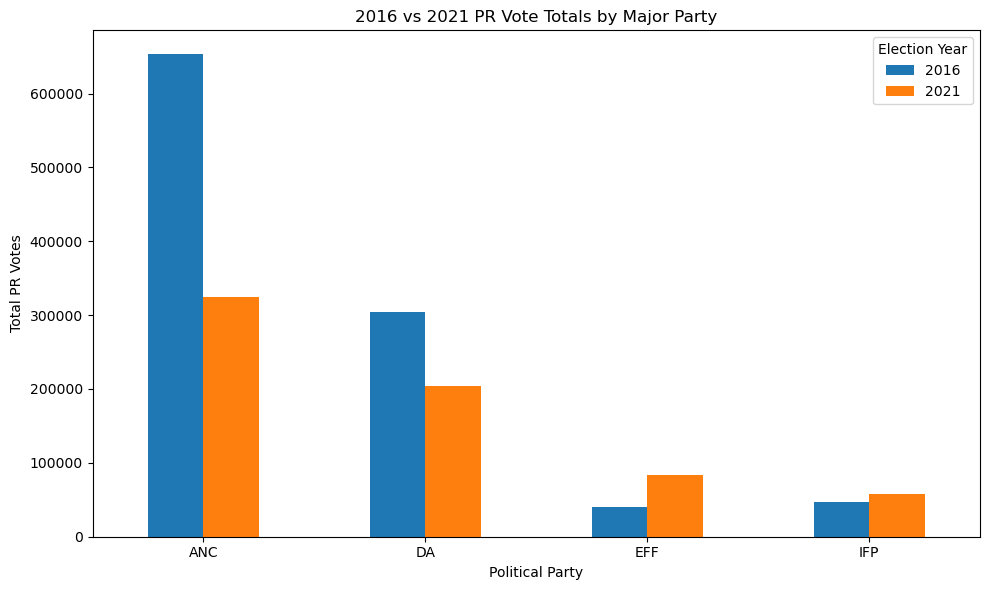

  Party    2016    2021
0   ANC  652891  325134
1    DA  304206  203926
2   EFF   40087   83010
3   IFP   47260   57312


In [69]:
party_vote_comparison = pd.DataFrame({
    "Party": ["ANC", "DA", "EFF", "IFP"],
    "2016": [
        master_df["ANC_Votes_2016"].sum(),
        master_df["DA_Votes_2016"].sum(),
        master_df["EFF_Votes_2016"].sum(),
        master_df["IFP_Votes_2016"].sum()
    ],
    "2021": [
        master_df["ANC_Votes_2021"].sum(),
        master_df["DA_Votes_2021"].sum(),
        master_df["EFF_Votes_2021"].sum(),
        master_df["IFP_Votes_2021"].sum()
    ]
})

ax = party_vote_comparison.set_index("Party").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("2016 vs 2021 PR Vote Totals by Major Party")
plt.xlabel("Political Party")
plt.ylabel("Total PR Votes")
plt.xticks(rotation=0)
plt.legend(title="Election Year")
plt.tight_layout()
plt.show()

print(party_vote_comparison)

## Visualization 2: Party Vote Share Distribution Across Wards

Boxplots are used to examine the distribution of party PR vote shares across the 110 comparable wards.

Unlike the previous bar chart, which shows aggregate metropolitan totals, this visualization shows the variation between individual wards.

The boxplots help identify the median level of support, variation between wards and potential outlier wards.

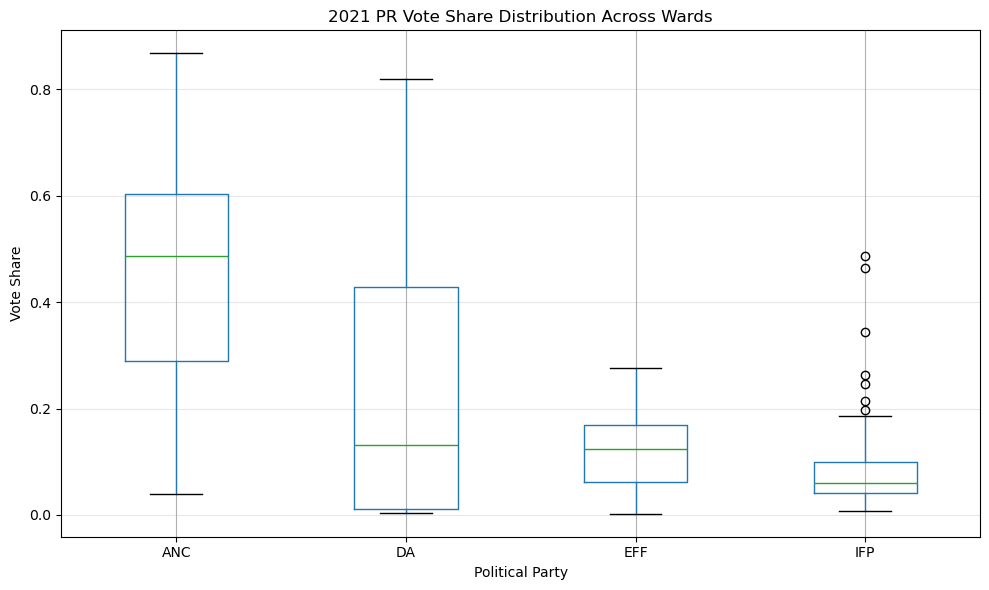

In [70]:
share_data = master_df[
    [
        "ANC_Share_2021",
        "DA_Share_2021",
        "EFF_Share_2021",
        "IFP_Share_2021"
    ]
].copy()

share_data.columns = ["ANC", "DA", "EFF", "IFP"]

plt.figure(figsize=(10, 6))

share_data.boxplot()

plt.title("2021 PR Vote Share Distribution Across Wards")
plt.xlabel("Political Party")
plt.ylabel("Vote Share")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

The boxplot shows substantial variation in party vote shares across the 110 wards.

The ANC has a relatively high median vote share, although support varies considerably between wards. The DA also shows substantial variation, indicating that its support is concentrated more strongly in some wards than others.

The EFF has a lower median vote share than the ANC and DA but shows a noticeable increase in support across many wards. The IFP also shows variation between wards, with some wards having substantially higher IFP support than the majority.

The presence of variation and outliers demonstrates that electoral patterns differ considerably between wards. This supports the use of ward-level historical and demographic features in the machine learning models.

## Visualization 3: Demographic Composition and Party Support

A scatter plot is used to examine the relationship between the proportion of residents aged 0–24 and the 2021 EFF PR vote share across wards.

Each point represents one of the 110 comparable wards.

The purpose is exploratory rather than causal. The visualization is used to identify whether a relationship exists that may be useful for subsequent machine learning analysis.

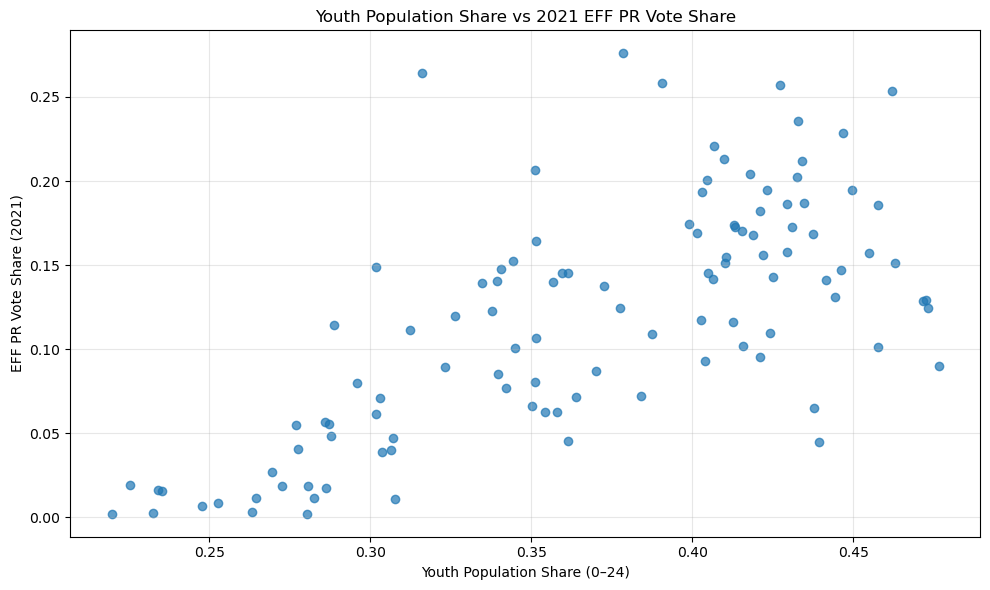

Pearson correlation: 0.693


In [71]:
plt.figure(figsize=(10, 6))

plt.scatter(
    master_df["Youth_Share"],
    master_df["EFF_Share_2021"],
    alpha=0.7
)

plt.title("Youth Population Share vs 2021 EFF PR Vote Share")
plt.xlabel("Youth Population Share (0–24)")
plt.ylabel("EFF PR Vote Share (2021)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

correlation = master_df["Youth_Share"].corr(
    master_df["EFF_Share_2021"]
)

print(f"Pearson correlation: {correlation:.3f}")

### Interpretation

The scatter plot shows the relationship between the proportion of the population aged 0–24 and EFF PR vote share across the 110 comparable eThekwini wards.

The points show that wards differ in both their demographic composition and their level of EFF support. The correlation value provides an indication of the strength and direction of the linear relationship between these two variables.

The relationship should not be interpreted as proof that demographic composition causes voting behaviour. Instead, it demonstrates why demographic variables can be included as additional features when developing the machine learning models.

Overall, the EDA shows that electoral support varies considerably across wards and that both historical election performance and demographic characteristics may provide useful information for modelling.

# Feature Engineering

## Historical Electoral Change

Feature engineering transforms the prepared election and demographic data into variables that can be used by machine learning algorithms.

The 2016 election results provide historical information about party support, while the 2021 results allow us to measure how party support changed between elections.

Change in party vote share is calculated for the ANC, DA, EFF and IFP.

In [72]:
# Calculate change in party vote share between 2016 and 2021

for party in ["ANC", "DA", "EFF", "IFP"]:
    master_df[f"{party}_Share_Change"] = (
        master_df[f"{party}_Share_2021"] -
        master_df[f"{party}_Share_2016"]
    )

# Display the historical change features
change_columns = [
    "Ward_Code",
    "ANC_Share_Change",
    "DA_Share_Change",
    "EFF_Share_Change",
    "IFP_Share_Change"
]

display(master_df[change_columns].head(10))

,Ward_Code,ANC_Share_Change,DA_Share_Change,EFF_Share_Change,IFP_Share_Change
0,59500001,-0.057810,-0.010478,0.034749,0.002391
1,59500002,-0.114757,-0.001081,0.079687,0.016320
2,59500003,-0.168100,-0.011300,0.090968,0.042611
3,59500004,0.029314,-0.037214,0.022838,0.002431
4,59500005,-0.276971,-0.005738,0.226923,0.027348
5,59500006,-0.167453,-0.017413,0.133095,0.006472
6,59500007,-0.172456,-0.018565,0.068879,0.010622
7,59500008,-0.095763,-0.016757,0.039988,0.003458
8,59500009,-0.095489,-0.062811,0.031881,0.009514
9,59500010,-0.016218,-0.126011,0.003527,0.005114


## Creating the Machine Learning Target

For the classification models, the target variable is the party that received the largest PR vote share in each ward in the 2021 election.

The target is created from the four consistently relevant parties included in the analysis: ANC, DA, EFF and IFP.

This allows the machine learning models to learn the relationship between historical electoral performance and ward demographics and the observed 2021 leading party.

In [73]:
# Identify the leading party in each ward in the 2021 election

vote_columns_2021 = [
    "ANC_Votes_2021",
    "DA_Votes_2021",
    "EFF_Votes_2021",
    "IFP_Votes_2021"
]

master_df["Leading_Party_2021"] = (
    master_df[vote_columns_2021]
    .idxmax(axis=1)
    .str.replace("_Votes_2021", "", regex=False)
)

print("2021 Leading Party Distribution:")
print(master_df["Leading_Party_2021"].value_counts())

print("\nSample:")
display(
    master_df[
        ["Ward_Code", "ANC_Votes_2021", "DA_Votes_2021",
         "EFF_Votes_2021", "IFP_Votes_2021", "Leading_Party_2021"]
    ].head(10)
)

2021 Leading Party Distribution:
Leading_Party_2021
ANC    74
DA     34
IFP     2
Name: count, dtype: int64

Sample:


,Ward_Code,ANC_Votes_2021,DA_Votes_2021,EFF_Votes_2021,IFP_Votes_2021,Leading_Party_2021
0,59500001,8824,177,457,77,ANC
1,59500002,6818,120,895,446,ANC
2,59500003,4118,50,839,727,ANC
3,59500004,6792,244,555,206,ANC
4,59500005,3992,44,1622,286,ANC
5,59500006,5305,27,1352,804,ANC
6,59500007,4305,1111,731,321,ANC
7,59500008,4877,2912,604,209,ANC
8,59500009,4369,3554,459,256,ANC
9,59500010,572,8852,100,96,DA


## Preparing Features for Machine Learning

The machine learning classification models will use information that would have been available before the 2021 election.

The predictor variables therefore consist of:

- 2016 PR vote shares for ANC, DA, EFF and IFP
- 2016 total PR votes
- Ward population
- Youth population share
- Working-age population share
- Older population share

The 2021 leading party is retained as the target variable.

2021 electoral results are not used as input features because doing so would cause data leakage.

In [74]:
# Define predictor features available before the 2021 election

feature_columns = [
    "ANC_Share_2016",
    "DA_Share_2016",
    "EFF_Share_2016",
    "IFP_Share_2016",
    "TotalPRVotes_2016",
    "Total",
    "Youth_Share",
    "WorkingAge_Share",
    "Older_Share"
]

X = master_df[feature_columns].copy()
y = master_df["Leading_Party_2021"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nMissing values:")
print(X.isnull().sum().sum())

print("\nTarget classes:")
print(y.value_counts())

Feature matrix shape: (110, 9)
Target shape: (110,)

Features:
['ANC_Share_2016', 'DA_Share_2016', 'EFF_Share_2016', 'IFP_Share_2016', 'TotalPRVotes_2016', 'Total', 'Youth_Share', 'WorkingAge_Share', 'Older_Share']

Missing values:
0

Target classes:
Leading_Party_2021
ANC    74
DA     34
IFP     2
Name: count, dtype: int64


# Machine Learning Implementation

## Training and Testing Data

The dataset is divided into training and testing subsets.

The training data is used to develop the machine learning models, while the testing data is used to evaluate how well the models perform on unseen observations.

Stratified sampling is used to preserve the distribution of the leading-party classes as far as possible, which is particularly important because IFP leads in only two wards.

In [75]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set: (88, 9)
Testing set: (22, 9)

Training target distribution:
Leading_Party_2021
ANC    59
DA     27
IFP     2
Name: count, dtype: int64

Testing target distribution:
Leading_Party_2021
ANC    15
DA      7
Name: count, dtype: int64


## Revised Training, Validation and Testing Split

The dataset is divided into approximately 70% training, 15% validation and 15% testing data, following the recommended machine learning workflow.

The training set is used to fit the models, the validation set is used to compare and tune models, and the testing set is reserved for final evaluation.

Because the IFP is the leading party in only two of the 110 comparable wards, it is not possible to guarantee representation of this minority class in all three subsets. This limitation is documented and considered when interpreting model performance.

In [77]:
# 70% Training, 15% Validation, 15% Testing

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

# Split the remaining 85% into approximately 70% training
# and 15% validation of the original dataset
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=(15 / 85),
    random_state=42,
    stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Testing set:", X_test.shape)

print("\nTraining distribution:")
print(y_train.value_counts())

print("\nValidation distribution:")
print(y_val.value_counts())

print("\nTesting distribution:")
print(y_test.value_counts())

Training set: (76, 9)
Validation set: (17, 9)
Testing set: (17, 9)

Training distribution:
Leading_Party_2021
ANC    51
DA     24
IFP     1
Name: count, dtype: int64

Validation distribution:
Leading_Party_2021
ANC    11
DA      5
IFP     1
Name: count, dtype: int64

Testing distribution:
Leading_Party_2021
ANC    12
DA      5
Name: count, dtype: int64


In [78]:
# Logistic Regression with validation-set evaluation

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

# Train using the training set
logistic_model.fit(X_train, y_train)

# Validation predictions
y_pred_val_logistic = logistic_model.predict(X_val)

# Validation metrics
val_accuracy_logistic = accuracy_score(y_val, y_pred_val_logistic)
val_precision_logistic = precision_score(
    y_val, y_pred_val_logistic,
    average="weighted",
    zero_division=0
)
val_recall_logistic = recall_score(
    y_val, y_pred_val_logistic,
    average="weighted",
    zero_division=0
)
val_f1_logistic = f1_score(
    y_val, y_pred_val_logistic,
    average="weighted",
    zero_division=0
)

print("LOGISTIC REGRESSION - VALIDATION RESULTS")
print("=" * 50)
print(f"Accuracy : {val_accuracy_logistic:.3f}")
print(f"Precision: {val_precision_logistic:.3f}")
print(f"Recall   : {val_recall_logistic:.3f}")
print(f"F1 Score : {val_f1_logistic:.3f}")

print("\nValidation Classification Report:")
print(classification_report(
    y_val,
    y_pred_val_logistic,
    zero_division=0
))

LOGISTIC REGRESSION - VALIDATION RESULTS
Accuracy : 0.941
Precision: 0.951
Recall   : 0.941
F1 Score : 0.942

Validation Classification Report:
              precision    recall  f1-score   support

         ANC       1.00      0.91      0.95        11
          DA       0.83      1.00      0.91         5
         IFP       1.00      1.00      1.00         1

    accuracy                           0.94        17
   macro avg       0.94      0.97      0.95        17
weighted avg       0.95      0.94      0.94        17



In [80]:
# Compare training and validation performance

y_pred_train_logistic = logistic_model.predict(X_train)

train_accuracy_logistic = accuracy_score(
    y_train,
    y_pred_train_logistic
)

print("LOGISTIC REGRESSION FIT CHECK")
print("=" * 45)
print(f"Training Accuracy  : {train_accuracy_logistic:.3f}")
print(f"Validation Accuracy: {val_accuracy_logistic:.3f}")
print(f"Difference         : {train_accuracy_logistic - val_accuracy_logistic:.3f}")

LOGISTIC REGRESSION FIT CHECK
Training Accuracy  : 1.000
Validation Accuracy: 0.941
Difference         : 0.059


## Logistic Regression Regularization

The initial Logistic Regression model achieved very high training accuracy compared with validation accuracy, indicating mild overfitting.

To improve generalisation, regularization is introduced. A smaller value of the parameter `C` applies stronger regularization and reduces the tendency of the model to fit the training data too closely.

The regularized model will be compared with the original model using both training and validation performance.

In [81]:
# Regularized Logistic Regression

regularized_logistic = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        C=0.1,
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

# Train the regularized model
regularized_logistic.fit(X_train, y_train)

# Predictions
y_pred_train_reg = regularized_logistic.predict(X_train)
y_pred_val_reg = regularized_logistic.predict(X_val)

# Accuracy
train_acc_reg = accuracy_score(y_train, y_pred_train_reg)
val_acc_reg = accuracy_score(y_val, y_pred_val_reg)

print("REGULARIZED LOGISTIC REGRESSION")
print("=" * 50)
print(f"Training Accuracy  : {train_acc_reg:.3f}")
print(f"Validation Accuracy: {val_acc_reg:.3f}")
print(f"Difference         : {train_acc_reg - val_acc_reg:.3f}")

REGULARIZED LOGISTIC REGRESSION
Training Accuracy  : 0.974
Validation Accuracy: 0.941
Difference         : 0.033


In [82]:
# Decision Tree Classifier

decision_tree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

# Train the model
decision_tree.fit(X_train, y_train)

# Predictions
y_pred_train_tree = decision_tree.predict(X_train)
y_pred_val_tree = decision_tree.predict(X_val)

# Calculate metrics
train_acc_tree = accuracy_score(y_train, y_pred_train_tree)
val_acc_tree = accuracy_score(y_val, y_pred_val_tree)

val_precision_tree = precision_score(
    y_val, y_pred_val_tree,
    average="weighted",
    zero_division=0
)

val_recall_tree = recall_score(
    y_val, y_pred_val_tree,
    average="weighted",
    zero_division=0
)

val_f1_tree = f1_score(
    y_val, y_pred_val_tree,
    average="weighted",
    zero_division=0
)

print("DECISION TREE RESULTS")
print("=" * 50)
print(f"Training Accuracy  : {train_acc_tree:.3f}")
print(f"Validation Accuracy: {val_acc_tree:.3f}")
print(f"Difference         : {train_acc_tree - val_acc_tree:.3f}")
print(f"Validation Precision: {val_precision_tree:.3f}")
print(f"Validation Recall   : {val_recall_tree:.3f}")
print(f"Validation F1 Score : {val_f1_tree:.3f}")

print("\nValidation Classification Report:")
print(classification_report(
    y_val,
    y_pred_val_tree,
    zero_division=0
))

DECISION TREE RESULTS
Training Accuracy  : 0.987
Validation Accuracy: 0.941
Difference         : 0.046
Validation Precision: 0.946
Validation Recall   : 0.941
Validation F1 Score : 0.939

Validation Classification Report:
              precision    recall  f1-score   support

         ANC       0.92      1.00      0.96        11
          DA       1.00      0.80      0.89         5
         IFP       1.00      1.00      1.00         1

    accuracy                           0.94        17
   macro avg       0.97      0.93      0.95        17
weighted avg       0.95      0.94      0.94        17



## Cross-Validation for Generalisation

Although regularization reduced the training-validation gap, the dataset contains only 110 comparable wards and the validation set contains only 17 wards.

Therefore, a single train-validation split may give an unstable estimate of model performance.

Cross-validation is used as an additional generalisation check. Because the IFP class contains only two wards, reliable multi-fold stratified validation cannot be performed for all three classes.

For this reason, cross-validation is performed on the two classes with sufficient observations: ANC and DA.

This provides a more robust assessment of whether Logistic Regression generalises beyond the particular validation split.

In [83]:
# Cross-validation on the sufficiently represented ANC and DA classes

cv_data = master_df[
    master_df["Leading_Party_2021"].isin(["ANC", "DA"])
].copy()

X_cv = cv_data[feature_columns]
y_cv = cv_data["Leading_Party_2021"]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    regularized_logistic,
    X_cv,
    y_cv,
    cv=cv,
    scoring="accuracy"
)

print("REGULARIZED LOGISTIC REGRESSION - 5-FOLD CROSS-VALIDATION")
print("=" * 60)

print("Fold accuracies:")
for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i}: {score:.3f}")

print(f"\nMean CV Accuracy: {cv_scores.mean():.3f}")
print(f"Standard Deviation: {cv_scores.std():.3f}")

REGULARIZED LOGISTIC REGRESSION - 5-FOLD CROSS-VALIDATION
Fold accuracies:
Fold 1: 0.955
Fold 2: 0.955
Fold 3: 0.955
Fold 4: 0.952
Fold 5: 0.905

Mean CV Accuracy: 0.944
Standard Deviation: 0.020


## Cross-Validation Results Interpretation

The regularized Logistic Regression model achieved a mean 5-fold cross-validation accuracy of 94.4%, with a standard deviation of 2.0%.

The cross-validation result is very close to the validation accuracy of 94.1%. This consistency indicates that the model's performance is not dependent on a single validation split.

Although the training accuracy of 97.4% is higher than the validation accuracy of 94.1%, the relatively small difference of 3.3 percentage points, together with the stable cross-validation performance, suggests that the model has good generalisation.

The model is therefore considered to have only mild overfitting rather than severe overfitting.

Because the IFP class contains only two wards, the IFP results should be interpreted cautiously. The cross-validation analysis focuses on the ANC and DA classes because they have sufficient observations for reliable stratified folds.

# Decision Tree Classification

A Decision Tree classifier is implemented as a second machine learning approach.

Unlike Logistic Regression, which models a relationship between the input variables and class probabilities, a Decision Tree makes decisions using a sequence of feature-based rules.

The tree depth and minimum sample requirements are restricted to reduce overfitting.

The model will be evaluated using training and validation accuracy, precision, recall and F1-score.

In [84]:
# Decision Tree Classifier

decision_tree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

# Train the model
decision_tree.fit(X_train, y_train)

# Predictions
y_pred_train_tree = decision_tree.predict(X_train)
y_pred_val_tree = decision_tree.predict(X_val)

# Training accuracy
train_acc_tree = accuracy_score(
    y_train,
    y_pred_train_tree
)

# Validation metrics
val_acc_tree = accuracy_score(
    y_val,
    y_pred_val_tree
)

val_precision_tree = precision_score(
    y_val,
    y_pred_val_tree,
    average="weighted",
    zero_division=0
)

val_recall_tree = recall_score(
    y_val,
    y_pred_val_tree,
    average="weighted",
    zero_division=0
)

val_f1_tree = f1_score(
    y_val,
    y_pred_val_tree,
    average="weighted",
    zero_division=0
)

print("DECISION TREE RESULTS")
print("=" * 55)
print(f"Training Accuracy   : {train_acc_tree:.3f}")
print(f"Validation Accuracy : {val_acc_tree:.3f}")
print(f"Difference          : {train_acc_tree - val_acc_tree:.3f}")
print(f"Validation Precision: {val_precision_tree:.3f}")
print(f"Validation Recall   : {val_recall_tree:.3f}")
print(f"Validation F1 Score : {val_f1_tree:.3f}")

print("\nValidation Classification Report:")
print(classification_report(
    y_val,
    y_pred_val_tree,
    zero_division=0
))

DECISION TREE RESULTS
Training Accuracy   : 0.987
Validation Accuracy : 0.941
Difference          : 0.046
Validation Precision: 0.946
Validation Recall   : 0.941
Validation F1 Score : 0.939

Validation Classification Report:
              precision    recall  f1-score   support

         ANC       0.92      1.00      0.96        11
          DA       1.00      0.80      0.89         5
         IFP       1.00      1.00      1.00         1

    accuracy                           0.94        17
   macro avg       0.97      0.93      0.95        17
weighted avg       0.95      0.94      0.94        17



## Decision Tree Generalisation Check

The Decision Tree achieved 98.7% training accuracy and 94.1% validation accuracy, resulting in a 4.6 percentage-point difference.

This indicates some overfitting because the model performs better on the training data than on unseen validation data.

To determine whether this difference represents serious overfitting, 5-fold cross-validation is performed on the sufficiently represented ANC and DA classes.

The cross-validation results will provide a more reliable estimate of the model's generalisation performance.

In [85]:
# 5-Fold Cross-Validation for Decision Tree

tree_cv_scores = cross_val_score(
    decision_tree,
    X_cv,
    y_cv,
    cv=cv,
    scoring="accuracy"
)

print("DECISION TREE - 5-FOLD CROSS-VALIDATION")
print("=" * 55)

print("Fold accuracies:")

for i, score in enumerate(tree_cv_scores, 1):
    print(f"Fold {i}: {score:.3f}")

print(f"\nMean CV Accuracy: {tree_cv_scores.mean():.3f}")
print(f"Standard Deviation: {tree_cv_scores.std():.3f}")

DECISION TREE - 5-FOLD CROSS-VALIDATION
Fold accuracies:
Fold 1: 0.909
Fold 2: 1.000
Fold 3: 1.000
Fold 4: 0.952
Fold 5: 0.952

Mean CV Accuracy: 0.963
Standard Deviation: 0.034


## Decision Tree Cross-Validation Results Interpretation

The Decision Tree achieved a mean 5-fold cross-validation accuracy of 96.3%, with a standard deviation of 3.4%.

Although the training accuracy of 98.7% is higher than the validation accuracy of 94.1%, the cross-validation results indicate that the model performs consistently well across different subsets of the data.

The difference between the validation accuracy and the mean cross-validation accuracy is relatively small. Therefore, the Decision Tree shows mild overfitting rather than severe overfitting.

The constrained tree parameters, including a maximum depth of 4, also help limit excessive model complexity.

The Decision Tree will be retained and compared with Logistic Regression and Random Forest using the same evaluation criteria.

# Random Forest

In [86]:
# Random Forest Classifier

random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

# Train the model
random_forest.fit(X_train, y_train)

# Predictions
y_pred_train_rf = random_forest.predict(X_train)
y_pred_val_rf = random_forest.predict(X_val)

# Training accuracy
train_acc_rf = accuracy_score(
    y_train,
    y_pred_train_rf
)

# Validation metrics
val_acc_rf = accuracy_score(
    y_val,
    y_pred_val_rf
)

val_precision_rf = precision_score(
    y_val,
    y_pred_val_rf,
    average="weighted",
    zero_division=0
)

val_recall_rf = recall_score(
    y_val,
    y_pred_val_rf,
    average="weighted",
    zero_division=0
)

val_f1_rf = f1_score(
    y_val,
    y_pred_val_rf,
    average="weighted",
    zero_division=0
)

print("RANDOM FOREST RESULTS")
print("=" * 55)
print(f"Training Accuracy   : {train_acc_rf:.3f}")
print(f"Validation Accuracy : {val_acc_rf:.3f}")
print(f"Difference          : {train_acc_rf - val_acc_rf:.3f}")
print(f"Validation Precision: {val_precision_rf:.3f}")
print(f"Validation Recall   : {val_recall_rf:.3f}")
print(f"Validation F1 Score : {val_f1_rf:.3f}")

print("\nValidation Classification Report:")
print(classification_report(
    y_val,
    y_pred_val_rf,
    zero_division=0
))

RANDOM FOREST RESULTS
Training Accuracy   : 1.000
Validation Accuracy : 0.941
Difference          : 0.059
Validation Precision: 0.946
Validation Recall   : 0.941
Validation F1 Score : 0.939

Validation Classification Report:
              precision    recall  f1-score   support

         ANC       0.92      1.00      0.96        11
          DA       1.00      0.80      0.89         5
         IFP       1.00      1.00      1.00         1

    accuracy                           0.94        17
   macro avg       0.97      0.93      0.95        17
weighted avg       0.95      0.94      0.94        17



## Random Forest Tuning Results

The tuned Random Forest achieved a validation accuracy of 88.2%, compared with 94.1% for the original Random Forest.

The training accuracy remained at 100%, while the training-validation difference increased from 5.9 to 11.8 percentage points.

Therefore, the attempted tuning did not improve generalisation. The tuned model is not selected as the final Random Forest model.

The original Random Forest is retained for further evaluation, while the tuned model is documented as an unsuccessful hyperparameter adjustment.

This demonstrates that model improvement should be based on validation and cross-validation performance rather than simply reducing training accuracy.

In [88]:
# 5-Fold Cross-Validation for the Original Random Forest

rf_cv_scores = cross_val_score(
    random_forest,
    X_cv,
    y_cv,
    cv=cv,
    scoring="accuracy"
)

print("ORIGINAL RANDOM FOREST - 5-FOLD CROSS-VALIDATION")
print("=" * 60)

print("Fold accuracies:")

for i, score in enumerate(rf_cv_scores, 1):
    print(f"Fold {i}: {score:.3f}")

print(f"\nMean CV Accuracy: {rf_cv_scores.mean():.3f}")
print(f"Standard Deviation: {rf_cv_scores.std():.3f}")

ORIGINAL RANDOM FOREST - 5-FOLD CROSS-VALIDATION
Fold accuracies:
Fold 1: 0.909
Fold 2: 1.000
Fold 3: 1.000
Fold 4: 1.000
Fold 5: 0.952

Mean CV Accuracy: 0.972
Standard Deviation: 0.037


## Random Forest Cross-Validation Results

The original Random Forest achieved a mean 5-fold cross-validation accuracy of 97.2%, with a standard deviation of 3.7%.

This is the highest mean cross-validation accuracy among the three models tested.

However, the model achieved 100% training accuracy, indicating that some overfitting is present. The cross-validation results nevertheless show strong predictive performance across different subsets of the data.

The attempted hyperparameter tuning reduced validation accuracy from 94.1% to 88.2%, so the tuned Random Forest was not selected.

The original Random Forest is therefore retained as the strongest model based on cross-validation accuracy, while Logistic Regression remains attractive because it has a smaller cross-validation standard deviation and a smaller training-validation gap.

In [89]:
# Model Performance Comparison

model_comparison = pd.DataFrame({
    "Model": [
        "Regularized Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Validation Accuracy": [
        val_acc_reg,
        val_acc_tree,
        val_acc_rf
    ],
    "Validation Precision": [
        precision_score(y_val, y_pred_val_reg,
                        average="weighted", zero_division=0),
        val_precision_tree,
        val_precision_rf
    ],
    "Validation Recall": [
        recall_score(y_val, y_pred_val_reg,
                     average="weighted", zero_division=0),
        val_recall_tree,
        val_recall_rf
    ],
    "Validation F1": [
        f1_score(y_val, y_pred_val_reg,
                 average="weighted", zero_division=0),
        val_f1_tree,
        val_f1_rf
    ],
    "Mean CV Accuracy": [
        cv_scores.mean(),
        tree_cv_scores.mean(),
        rf_cv_scores.mean()
    ],
    "CV Std Dev": [
        cv_scores.std(),
        tree_cv_scores.std(),
        rf_cv_scores.std()
    ]
})

display(
    model_comparison.style.format({
        "Validation Accuracy": "{:.3f}",
        "Validation Precision": "{:.3f}",
        "Validation Recall": "{:.3f}",
        "Validation F1": "{:.3f}",
        "Mean CV Accuracy": "{:.3f}",
        "CV Std Dev": "{:.3f}"
    })
)

,Model,Validation Accuracy,Validation Precision,Validation Recall,Validation F1,Mean CV Accuracy,CV Std Dev
0,Regularized Logistic Regression,0.941,0.951,0.941,0.942,0.944,0.020
1,Decision Tree,0.941,0.946,0.941,0.939,0.963,0.034
2,Random Forest,0.941,0.946,0.941,0.939,0.972,0.037


## Final Model Selection

The three classification models were compared using validation accuracy, precision, recall, F1-score and 5-fold cross-validation.

All three models achieved 94.1% validation accuracy.

The Random Forest achieved the highest mean cross-validation accuracy at 97.2%, followed by the Decision Tree at 96.3% and Regularized Logistic Regression at 94.4%.

Although Random Forest has a larger training-validation gap and a slightly higher cross-validation standard deviation, its cross-validation accuracy indicates the strongest overall predictive performance.

Therefore, the Random Forest is selected as the final classification model for the election outcome analysis.

The model's limitations, including the small number of wards and the very small IFP class, will be acknowledged when interpreting the results.

<Figure size 700x600 with 0 Axes>

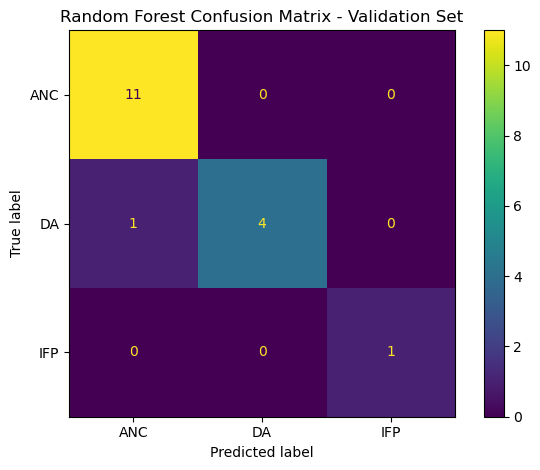

Confusion Matrix:
[[11  0  0]
 [ 1  4  0]
 [ 0  0  1]]


In [91]:
# Confusion Matrix for the Selected Random Forest Model

cm_rf = confusion_matrix(
    y_val,
    y_pred_val_rf,
    labels=["ANC", "DA", "IFP"]
)

plt.figure(figsize=(7, 6))

ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["ANC", "DA", "IFP"]
).plot()

plt.title("Random Forest Confusion Matrix - Validation Set")
plt.tight_layout()
plt.show()

print("Confusion Matrix:")
print(cm_rf)

## Random Forest Confusion Matrix Interpretation

The confusion matrix shows that the Random Forest correctly classified 16 of the 17 validation wards.

All 11 ANC-leading wards were correctly classified. Four of the five DA-leading wards were correctly classified, while one DA ward was incorrectly classified as ANC.

The single IFP-leading ward in the validation set was correctly classified. However, IFP has only two leading wards in the complete dataset, so this result should be interpreted cautiously.

The confusion matrix therefore supports the strong validation performance of the Random Forest, while also highlighting the class imbalance and limited number of IFP observations.

The EFF does not appear in the confusion matrix because no ward was led by the EFF among the four selected parties in the 2021 target data.

In [92]:
# Final Test Evaluation - Selected Random Forest

# Predict on the completely unseen test set
y_pred_test_rf = random_forest.predict(X_test)

# Calculate test metrics
test_accuracy_rf = accuracy_score(y_test, y_pred_test_rf)
test_precision_rf = precision_score(
    y_test,
    y_pred_test_rf,
    average="weighted",
    zero_division=0
)
test_recall_rf = recall_score(
    y_test,
    y_pred_test_rf,
    average="weighted",
    zero_division=0
)
test_f1_rf = f1_score(
    y_test,
    y_pred_test_rf,
    average="weighted",
    zero_division=0
)

print("FINAL RANDOM FOREST - TEST RESULTS")
print("=" * 60)
print(f"Test Accuracy   : {test_accuracy_rf:.3f}")
print(f"Test Precision  : {test_precision_rf:.3f}")
print(f"Test Recall     : {test_recall_rf:.3f}")
print(f"Test F1 Score   : {test_f1_rf:.3f}")

print("\nTest Classification Report:")
print(classification_report(
    y_test,
    y_pred_test_rf,
    zero_division=0
))

FINAL RANDOM FOREST - TEST RESULTS
Test Accuracy   : 0.941
Test Precision  : 0.951
Test Recall     : 0.941
Test F1 Score   : 0.943

Test Classification Report:
              precision    recall  f1-score   support

         ANC       1.00      0.92      0.96        12
          DA       0.83      1.00      0.91         5

    accuracy                           0.94        17
   macro avg       0.92      0.96      0.93        17
weighted avg       0.95      0.94      0.94        17



## Final Test Evaluation Interpretation

The final Random Forest model was evaluated on the unseen test set containing 17 wards.

The model achieved:

- Test Accuracy: 94.1%
- Test Precision: 95.1%
- Test Recall: 94.1%
- Test F1 Score: 94.3%

The test accuracy is the same as the validation accuracy of 94.1%. This consistency indicates that the model performs similarly on previously unseen data and is not heavily dependent on the validation sample.

The model correctly identified 11 of the 12 ANC-leading wards and all 5 DA-leading wards in the test set.

The results provide sufficient evidence to use the Random Forest as the selected classification model for the subsequent ward-level election outcome projection.

However, the results should be interpreted with caution because the analysis contains only 110 comparable wards and the target classes are imbalanced.

In [94]:
# Select Three Representative Wards for Detailed Analysis

# Calculate the leading party and winning share for each ward
ward_analysis = master_df[
    [
        "Ward_Code",
        "ANC_Share_2016",
        "DA_Share_2016",
        "EFF_Share_2016",
        "IFP_Share_2016",
        "ANC_Share_2021",
        "DA_Share_2021",
        "EFF_Share_2021",
        "IFP_Share_2021"
    ]
].copy()

share_columns = {
    "ANC": "ANC_Share_2021",
    "DA": "DA_Share_2021",
    "EFF": "EFF_Share_2021",
    "IFP": "IFP_Share_2021"
}

ward_analysis["Leading_Party"] = (
    ward_analysis[list(share_columns.values())]
    .idxmax(axis=1)
    .map({v: k for k, v in share_columns.items()})
)

ward_analysis["Winning_Share"] = (
    ward_analysis[list(share_columns.values())].max(axis=1)
)

# Calculate the difference between the highest and second-highest party
sorted_shares = np.sort(
    ward_analysis[list(share_columns.values())].values,
    axis=1
)

ward_analysis["Winning_Margin"] = (
    sorted_shares[:, -1] - sorted_shares[:, -2]
)

# 1. Strong ANC ward
anc_ward = (
    ward_analysis[
        ward_analysis["Leading_Party"] == "ANC"
    ]
    .sort_values("Winning_Share", ascending=False)
    .iloc[0]
)

# 2. Strong DA ward
da_ward = (
    ward_analysis[
        ward_analysis["Leading_Party"] == "DA"
    ]
    .sort_values("Winning_Share", ascending=False)
    .iloc[0]
)

# 3. Most competitive ward among the common wards
competitive_ward = (
    ward_analysis
    .sort_values("Winning_Margin", ascending=True)
    .iloc[0]
)

selected_wards = [
    anc_ward["Ward_Code"],
    da_ward["Ward_Code"],
    competitive_ward["Ward_Code"]
]

print("SELECTED REPRESENTATIVE WARDS")
print("=" * 60)
print(f"ANC-dominant ward: {anc_ward['Ward_Code']}")
print(f"DA-dominant ward : {da_ward['Ward_Code']}")
print(f"Competitive ward : {competitive_ward['Ward_Code']}")

print("\nSelection details:")
display(
    ward_analysis[
        ward_analysis["Ward_Code"].isin(selected_wards)
    ].sort_values("Winning_Margin")
)

SELECTED REPRESENTATIVE WARDS
ANC-dominant ward: 59500001
DA-dominant ward : 59500036
Competitive ward : 59500026

Selection details:


,Ward_Code,ANC_Share_2016,DA_Share_2016,EFF_Share_2016,IFP_Share_2016,ANC_Share_2021,DA_Share_2021,EFF_Share_2021,IFP_Share_2021,Leading_Party,Winning_Share,Winning_Margin
25,59500026,0.513012,0.352798,0.047170,0.033832,0.316571,0.332725,0.114122,0.052371,DA,0.332725,0.016154
35,59500036,0.115470,0.847527,0.007812,0.008843,0.060781,0.819548,0.011800,0.015362,DA,0.819548,0.758767
0,59500001,0.925716,0.027887,0.010201,0.005183,0.867906,0.017409,0.044949,0.007574,ANC,0.867906,0.822957


## Selection of Three Representative Wards

Three wards were selected from the 110 wards that are geographically comparable between the 2016 and 2021 election datasets.

The selection was data-driven rather than arbitrary:

1. **Ward 59500001** was selected as an ANC-dominant ward because the ANC recorded very high PR support in 2021.
2. **Ward 59500036** was selected as a DA-dominant ward because the DA recorded very high PR support in 2021.
3. **Ward 59500026** was selected as a competitive ward because the difference between the leading parties was very small. The DA led the ANC by approximately 1.6 percentage points in 2021.

These three wards represent different electoral patterns: a strongly ANC-supporting ward, a strongly DA-supporting ward and a competitive ward.

All three wards existed in both the 2016 and 2021 datasets. Therefore, historical comparisons between the two elections are geographically defensible.

The selected wards will be used for the required ward-level analytical output and future election projection.

In [96]:
# Required Analytical Output 2:
# Projected Leading Party for the Three Selected Wards

selected_ward_features = master_df[
    master_df["Ward_Code"].isin(selected_wards)
][["Ward_Code"] + feature_columns].copy()

# Generate predicted leading party
selected_ward_features["Projected_Leading_Party"] = (
    random_forest.predict(
        selected_ward_features[feature_columns]
    )
)

# Generate prediction probabilities
prediction_probabilities = random_forest.predict_proba(
    selected_ward_features[feature_columns]
)

class_names = random_forest.classes_

for i, class_name in enumerate(class_names):
    selected_ward_features[
        f"{class_name}_Probability"
    ] = prediction_probabilities[:, i]

# Display the required ward-level output
ward_projection_columns = [
    "Ward_Code",
    "Projected_Leading_Party"
] + [
    f"{c}_Probability" for c in class_names
]

display(
    selected_ward_features[
        ward_projection_columns
    ].sort_values("Ward_Code")
)

,Ward_Code,Projected_Leading_Party,ANC_Probability,DA_Probability,IFP_Probability
0,59500001,ANC,0.992069,0.007931,0.000000
25,59500026,ANC,0.784386,0.167049,0.048565
35,59500036,DA,0.005960,0.965175,0.028865


## Three-Ward Projection Results

The selected Random Forest model was used to project the leading party for the three representative wards.

The model produced the following results:

- **Ward 59500001:** ANC projected as the leading party with a probability of approximately 99.2%.
- **Ward 59500026:** ANC projected as the leading party with a probability of approximately 78.4%.
- **Ward 59500036:** DA projected as the leading party with a probability of approximately 96.5%.

The results demonstrate different levels of model confidence across the three wards.

Ward 59500026 is particularly important because it was selected as the competitive ward. The model projects ANC as the leader despite the DA having a slightly higher observed PR vote share in 2021. This demonstrates that the machine learning model is producing an analytical projection based on the historical and demographic features rather than simply reporting the 2021 result.

These results should be interpreted as model projections and not as certainty about future election outcomes.

In [97]:
# Prepare features for projecting future party vote shares
# using the most recent 2021 election information.

projection_features = master_df[
    [
        "Ward_Code",
        "ANC_Share_2021",
        "DA_Share_2021",
        "EFF_Share_2021",
        "IFP_Share_2021",
        "TotalPRVotes_2021",
        "Total",
        "Youth_Share",
        "WorkingAge_Share",
        "Older_Share"
    ]
].copy()

print("Projection feature dataset:")
print("Rows:", projection_features.shape[0])
print("Columns:", projection_features.shape[1])

display(projection_features.head())

Projection feature dataset:
Rows: 110
Columns: 10


,Ward_Code,ANC_Share_2021,DA_Share_2021,EFF_Share_2021,IFP_Share_2021,TotalPRVotes_2021,Total,Youth_Share,WorkingAge_Share,Older_Share
0,59500001,0.867906,0.017409,0.044949,0.007574,10167,41226.130930,0.439375,0.509279,0.051346
1,59500002,0.772490,0.013596,0.101405,0.050533,8826,39291.078384,0.457709,0.486206,0.056085
2,59500003,0.635788,0.007720,0.129535,0.112243,6477,37862.597373,0.472722,0.481204,0.046073
3,59500004,0.794665,0.028548,0.064935,0.024102,8547,50231.732044,0.437690,0.510373,0.051937
4,59500005,0.624043,0.006878,0.253556,0.044708,6397,32702.513977,0.462122,0.487218,0.050660


In [98]:
# 11. Party Vote-Share Projection Models

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Features available for the projection
share_feature_columns = [
    "ANC_Share_2016",
    "DA_Share_2016",
    "EFF_Share_2016",
    "IFP_Share_2016",
    "TotalPRVotes_2016",
    "Total",
    "Youth_Share",
    "WorkingAge_Share",
    "Older_Share"
]

# Use the 2021 party shares as targets
projection_results = {}

for party in ["ANC", "DA", "EFF", "IFP"]:
    
    X_share = master_df[share_feature_columns]
    y_share = master_df[f"{party}_Share_2021"]
    
    # Train the regression model
    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=5,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    )
    
    model.fit(X_share, y_share)
    
    # Store model
    projection_results[party] = model
    
    # Training performance
    predicted = model.predict(X_share)
    
    mae = mean_absolute_error(y_share, predicted)
    rmse = np.sqrt(mean_squared_error(y_share, predicted))
    r2 = r2_score(y_share, predicted)
    
    print(f"{party} VOTE-SHARE MODEL")
    print("-" * 50)
    print(f"MAE : {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²  : {r2:.4f}")
    print()

ANC VOTE-SHARE MODEL
--------------------------------------------------
MAE : 0.0286
RMSE: 0.0363
R²  : 0.9699

DA VOTE-SHARE MODEL
--------------------------------------------------
MAE : 0.0149
RMSE: 0.0238
R²  : 0.9913

EFF VOTE-SHARE MODEL
--------------------------------------------------
MAE : 0.0164
RMSE: 0.0228
R²  : 0.8919

IFP VOTE-SHARE MODEL
--------------------------------------------------
MAE : 0.0143
RMSE: 0.0244
R²  : 0.8975



## Party Vote-Share Model Evaluation

Separate Random Forest regression models were developed for the ANC, DA, EFF and IFP.

The models produced the following training errors:

- ANC: MAE = 0.0286, RMSE = 0.0363, R² = 0.9699
- DA: MAE = 0.0149, RMSE = 0.0238, R² = 0.9913
- EFF: MAE = 0.0164, RMSE = 0.0228, R² = 0.8919
- IFP: MAE = 0.0143, RMSE = 0.0244, R² = 0.8975

The models show that the historical features contain useful information for estimating 2021 party vote shares.

However, these metrics are calculated on the training data and should not be interpreted as evidence of perfect future-election accuracy. The projection is subject to uncertainty because only two election years are available for the analysis.

The models will therefore be used as analytical projection tools rather than as guarantees of future election results.

In [99]:
#  Projected Vote Share for Each Relevant Party

# Use the most recent available election information
# to generate the projection inputs.

projection_X = master_df[share_feature_columns].copy()

# Generate projected share for each party
for party, model in projection_results.items():
    master_df[f"Projected_{party}_Share"] = model.predict(
        projection_X
    )

# Ensure shares remain within valid limits
for party in ["ANC", "DA", "EFF", "IFP"]:
    master_df[f"Projected_{party}_Share"] = (
        master_df[f"Projected_{party}_Share"].clip(0, 1)
    )

# Display projected shares for all wards
projected_share_columns = [
    "Ward_Code",
    "Projected_ANC_Share",
    "Projected_DA_Share",
    "Projected_EFF_Share",
    "Projected_IFP_Share"
]

display(
    master_df[projected_share_columns].head(10)
)

,Ward_Code,Projected_ANC_Share,Projected_DA_Share,Projected_EFF_Share,Projected_IFP_Share
0,59500001,0.754795,0.015564,0.097626,0.036715
1,59500002,0.728581,0.011416,0.123012,0.058300
2,59500003,0.611473,0.010019,0.153667,0.115602
3,59500004,0.681226,0.033155,0.123857,0.046808
4,59500005,0.665514,0.019234,0.193032,0.049084
5,59500006,0.618150,0.009361,0.152179,0.122618
6,59500007,0.549755,0.160501,0.114467,0.053374
7,59500008,0.466062,0.301535,0.077683,0.032134
8,59500009,0.393825,0.400695,0.049185,0.028884
9,59500010,0.055616,0.771702,0.007258,0.019051


In [100]:
# 1Required Analytical Output 3:
# Aggregate Projected Vote Share by Relevant Party

parties = ["ANC", "DA", "EFF", "IFP"]

metro_projection = pd.DataFrame({
    "Party": parties,
    "Projected_Vote_Share": [
        master_df["Projected_ANC_Share"].mean(),
        master_df["Projected_DA_Share"].mean(),
        master_df["Projected_EFF_Share"].mean(),
        master_df["Projected_IFP_Share"].mean()
    ]
})

# Convert to percentage
metro_projection["Projected_Vote_Share_Percent"] = (
    metro_projection["Projected_Vote_Share"] * 100
)

# Rank parties
metro_projection = metro_projection.sort_values(
    "Projected_Vote_Share",
    ascending=False
).reset_index(drop=True)

print("PROJECTED METRO-LEVEL PARTY VOTE SHARE")
print("=" * 60)

display(
    metro_projection[
        ["Party", "Projected_Vote_Share_Percent"]
    ].style.format({
        "Projected_Vote_Share_Percent": "{:.2f}%"
    })
)

PROJECTED METRO-LEVEL PARTY VOTE SHARE


,Party,Projected_Vote_Share_Percent
0,ANC,44.21%
1,DA,23.19%
2,EFF,11.85%
3,IFP,8.17%


## Interpretation of Projected Party Vote Shares

The projected metro-level vote shares indicate that the ANC is projected to receive the largest share among the four relevant parties, at approximately 44.21%.

The projected shares are:

- ANC: 44.21%
- DA: 23.19%
- EFF: 11.85%
- IFP: 8.17%

Together, these four parties account for approximately 87.42% of the projected vote share.

The remaining approximately 12.58% represents other political parties that were not included in the selected modelling group.

The results therefore indicate that the ANC is projected to be the largest individual party among the parties included in the model. These are model-based electoral projections and should not be interpreted as a prediction of which party will govern the municipality.

In [101]:
#  Calculate the 2021 PR Voting Base
# Registered voters must NOT be summed across party rows because
# the registered-voter value is repeated for each party.

pr_2021_raw = iec_2021[
    iec_2021["BallotType"] == "PR"
].copy()

# Check how many unique voting stations and districts exist
unique_station_count = pr_2021_raw[
    ["Ward_Code", "VotingDistrict", "VotingStationName"]
].drop_duplicates().shape[0]

unique_district_count = pr_2021_raw[
    ["Ward_Code", "VotingDistrict"]
].drop_duplicates().shape[0]

print("2021 PR unique voting-station records:", unique_station_count)
print("2021 PR unique voting-district records:", unique_district_count)

# Check whether RegisteredVoters is consistent within each
# ward + voting district + station combination.
registered_check = (
    pr_2021_raw
    .groupby(
        ["Ward_Code", "VotingDistrict", "VotingStationName"]
    )["RegisteredVoters"]
    .nunique()
)

print(
    "\nVoting units with inconsistent RegisteredVoters:",
    (registered_check > 1).sum()
)

# Create one row per unique voting station
registered_2021 = (
    pr_2021_raw[
        [
            "Ward_Code",
            "VotingDistrict",
            "VotingStationName",
            "RegisteredVoters"
        ]
    ]
    .drop_duplicates(
        subset=[
            "Ward_Code",
            "VotingDistrict",
            "VotingStationName"
        ]
    )
)

total_registered_2021 = registered_2021["RegisteredVoters"].sum()

print("\n2021 eThekwini PR Registered Voters")
print("=" * 50)
print(f"Total registered voters: {total_registered_2021:,}")

2021 PR unique voting-station records: 875
2021 PR unique voting-district records: 875

Voting units with inconsistent RegisteredVoters: 0

2021 eThekwini PR Registered Voters
Total registered voters: 1,909,125


In [102]:
# Ward-Level Registered Voters

ward_registered_2021 = (
    registered_2021
    .groupby("Ward_Code")["RegisteredVoters"]
    .sum()
    .reset_index()
)

print("Ward-level registered voter records:", len(ward_registered_2021))
print("Total registered voters:",
      f"{ward_registered_2021['RegisteredVoters'].sum():,}")

display(ward_registered_2021.head())

Ward-level registered voter records: 111
Total registered voters: 1,909,125


,Ward_Code,RegisteredVoters
0,59500001,18289
1,59500002,18664
2,59500003,15086
3,59500004,19776
4,59500005,14605


In [103]:
# Weighted Metro-Level Projected Vote Shares

# Add registered voters to the modelling dataset
master_df = master_df.merge(
    ward_registered_2021,
    on="Ward_Code",
    how="left"
)

# Calculate weighted projected votes for each party
for party in ["ANC", "DA", "EFF", "IFP"]:
    master_df[f"Projected_{party}_Votes"] = (
        master_df[f"Projected_{party}_Share"] *
        master_df["RegisteredVoters"]
    )

# Aggregate projected votes
weighted_projection = pd.DataFrame({
    "Party": ["ANC", "DA", "EFF", "IFP"],
    "Projected_Vote_Total": [
        master_df["Projected_ANC_Votes"].sum(),
        master_df["Projected_DA_Votes"].sum(),
        master_df["Projected_EFF_Votes"].sum(),
        master_df["Projected_IFP_Votes"].sum()
    ]
})

# Calculate weighted vote shares
weighted_projection["Projected_Vote_Share"] = (
    weighted_projection["Projected_Vote_Total"] /
    total_registered_2021
)

weighted_projection["Projected_Vote_Share_Percent"] = (
    weighted_projection["Projected_Vote_Share"] * 100
)

weighted_projection = weighted_projection.sort_values(
    "Projected_Vote_Total",
    ascending=False
).reset_index(drop=True)

print("WEIGHTED METRO-LEVEL ELECTION PROJECTION")
print("=" * 65)

display(
    weighted_projection[
        [
            "Party",
            "Projected_Vote_Total",
            "Projected_Vote_Share_Percent"
        ]
    ].style.format({
        "Projected_Vote_Total": "{:,.0f}",
        "Projected_Vote_Share_Percent": "{:.2f}%"
    })
)

print(
    "\nProjected share represented by selected parties:",
    f"{weighted_projection['Projected_Vote_Share_Percent'].sum():.2f}%"
)

print(
    "Remaining share for other parties:",
    f"{100 - weighted_projection['Projected_Vote_Share_Percent'].sum():.2f}%"
)

WEIGHTED METRO-LEVEL ELECTION PROJECTION


,Party,Projected_Vote_Total,Projected_Vote_Share_Percent
0,ANC,"827,435",43.34%
1,DA,"454,948",23.83%
2,EFF,"220,111",11.53%
3,IFP,"150,196",7.87%



Projected share represented by selected parties: 86.57%
Remaining share for other parties: 13.43%


##  Interpretation of the Weighted Metro-Level Projection

The weighted projection estimates that the ANC will receive the largest aggregate vote total among the relevant parties, with approximately 827,435 projected votes and a projected vote share of 43.34%.

The DA is projected to receive approximately 454,948 votes (23.83%), followed by the EFF with approximately 220,111 votes (11.53%) and the IFP with approximately 150,196 votes (7.87%).

The four modelled parties account for approximately 86.57% of the projected vote share. The remaining 13.43% represents other parties that were not included in the selected modelling group.

The ANC is therefore projected to be the largest individual party, but its projected share is below 50%.

A vote-share result below 50% means that an outright majority cannot be inferred from the projected vote share alone. In a South African municipal election, council representation and coalition formation depend on the final allocation of council seats and other relevant election results.

Therefore, this analysis does not predict which party will govern the municipality. It only reports the machine learning projection of electoral support.

In [104]:
# 2021 Actual PR Voting Activity

# Aggregate party results to the voting-station level.
# Each station has multiple party rows, so party rows must
# not be counted as individual voters.

station_votes_2021 = (
    iec_2021[
        iec_2021["BallotType"] == "PR"
    ]
    .groupby(
        [
            "Ward_Code",
            "VotingDistrict",
            "VotingStationName"
        ]
    )
    .agg(
        ValidVotes=("TotalValidVotes", "sum"),
        RegisteredVoters=("RegisteredVoters", "first"),
        SpoiltVotes=("SpoiltVotes", "first")
    )
    .reset_index()
)

# Calculate total valid and spoilt votes
total_valid_votes_2021 = station_votes_2021["ValidVotes"].sum()
total_spoilt_votes_2021 = station_votes_2021["SpoiltVotes"].sum()

# Calculate turnout based on valid + spoilt ballots
total_ballots_2021 = (
    total_valid_votes_2021 +
    total_spoilt_votes_2021
)

actual_turnout_rate_2021 = (
    total_ballots_2021 /
    total_registered_2021
) * 100

print("2021 eThekwini PR VOTER TURNOUT")
print("=" * 60)
print(f"Registered voters : {total_registered_2021:,.0f}")
print(f"Valid votes       : {total_valid_votes_2021:,.0f}")
print(f"Spoilt votes      : {total_spoilt_votes_2021:,.0f}")
print(f"Total ballots     : {total_ballots_2021:,.0f}")
print(f"Turnout rate      : {actual_turnout_rate_2021:.2f}%")

2021 eThekwini PR VOTER TURNOUT
Registered voters : 1,909,125
Valid votes       : 774,736
Spoilt votes      : 18,087
Total ballots     : 792,823
Turnout rate      : 41.53%


In [105]:
# Historical Turnout Comparison: 2016 vs 2021

def calculate_pr_turnout(df):
    pr_data = df[df["BallotType"] == "PR"].copy()

    station_data = (
        pr_data
        .groupby(
            ["Ward_Code", "VotingDistrict", "VotingStationName"]
        )
        .agg(
            ValidVotes=("TotalValidVotes", "sum"),
            RegisteredVoters=("RegisteredVoters", "first"),
            SpoiltVotes=("SpoiltVotes", "first")
        )
        .reset_index()
    )

    registered = station_data["RegisteredVoters"].sum()
    valid_votes = station_data["ValidVotes"].sum()
    spoilt_votes = station_data["SpoiltVotes"].sum()
    ballots = valid_votes + spoilt_votes
    turnout = (ballots / registered) * 100

    return registered, valid_votes, spoilt_votes, ballots, turnout


registered_2016, valid_2016, spoilt_2016, ballots_2016, turnout_2016 = (
    calculate_pr_turnout(iec_2016)
)

print("HISTORICAL PR TURNOUT COMPARISON")
print("=" * 65)

print(f"2016 Registered voters : {registered_2016:,.0f}")
print(f"2016 Valid votes       : {valid_2016:,.0f}")
print(f"2016 Spoilt votes      : {spoilt_2016:,.0f}")
print(f"2016 Total ballots     : {ballots_2016:,.0f}")
print(f"2016 Turnout rate      : {turnout_2016:.2f}%")

print()

print(f"2021 Registered voters : {total_registered_2021:,.0f}")
print(f"2021 Valid votes       : {total_valid_votes_2021:,.0f}")
print(f"2021 Spoilt votes      : {total_spoilt_votes_2021:,.0f}")
print(f"2021 Total ballots     : {total_ballots_2021:,.0f}")
print(f"2021 Turnout rate      : {actual_turnout_rate_2021:.2f}%")

print()

print(
    f"Change in turnout rate : "
    f"{actual_turnout_rate_2021 - turnout_2016:+.2f} percentage points"
)

HISTORICAL PR TURNOUT COMPARISON
2016 Registered voters : 1,919,724
2016 Valid votes       : 1,104,552
2016 Spoilt votes      : 29,978
2016 Total ballots     : 1,134,530
2016 Turnout rate      : 59.10%

2021 Registered voters : 1,909,125
2021 Valid votes       : 774,736
2021 Spoilt votes      : 18,087
2021 Total ballots     : 792,823
2021 Turnout rate      : 41.53%

Change in turnout rate : -17.57 percentage points


## Historical Turnout Interpretation

The historical analysis shows a substantial decrease in PR voter turnout between the 2016 and 2021 elections.

Turnout decreased from 59.10% in 2016 to 41.53% in 2021, representing a decline of 17.57 percentage points.

This historical change demonstrates that voter participation can vary considerably between election periods.

Because only two election observations are available, directly extrapolating the full 17.57 percentage-point decline into the next election would be unreliable and could produce an unrealistic estimate.

Therefore, the turnout projection will be treated as an estimated analytical scenario rather than a guaranteed outcome. The projected number of voters will be calculated from the estimated turnout rate and the latest available registered-voter base.

In [106]:
# Projected Voter Turnout

# Conservative scenario estimate:
# midpoint between the observed 2016 and 2021 turnout rates.

projected_turnout_rate = (
    turnout_2016 + actual_turnout_rate_2021
) / 2

# Use the latest available registered-voter base
projected_voters = (
    total_registered_2021 *
    projected_turnout_rate / 100
)

projected_non_voters = (
    total_registered_2021 -
    projected_voters
)

print("PROJECTED eTHEKWINI PR VOTER TURNOUT")
print("=" * 65)
print(f"Registered voter base : {total_registered_2021:,.0f}")
print(f"2016 turnout          : {turnout_2016:.2f}%")
print(f"2021 turnout          : {actual_turnout_rate_2021:.2f}%")
print(f"Projected turnout     : {projected_turnout_rate:.2f}%")
print(f"Projected voters      : {projected_voters:,.0f}")
print(f"Estimated non-voters  : {projected_non_voters:,.0f}")

PROJECTED eTHEKWINI PR VOTER TURNOUT
Registered voter base : 1,909,125
2016 turnout          : 59.10%
2021 turnout          : 41.53%
Projected turnout     : 50.31%
Projected voters      : 960,545
Estimated non-voters  : 948,580


## Projected Turnout Interpretation

The estimated PR voter turnout for eThekwini is **50.31%**, based on the midpoint between the observed 2016 turnout of 59.10% and the 2021 turnout of 41.53%.

Using the latest available registered-voter base of **1,909,125**, the estimated number of voters participating is approximately **960,545**.

This is a scenario-based estimate rather than a guaranteed turnout prediction. The estimate uses the latest available voter registration base because a future official voter register was not available for this analysis.

In [107]:
# Final Metro-Level Party Projection

parties = ["ANC", "DA", "EFF", "IFP"]

# Calculate registered-voter-weighted projected share
final_projection = []

for party in parties:
    weighted_share = (
        master_df[f"Projected_{party}_Share"] *
        master_df["RegisteredVoters"]
    ).sum() / total_registered_2021
    
    final_projection.append({
        "Party": party,
        "Projected_Vote_Share": weighted_share
    })

final_projection = pd.DataFrame(final_projection)

# Calculate residual share for parties not included in the model
other_share = 1 - final_projection["Projected_Vote_Share"].sum()

final_projection = pd.concat([
    final_projection,
    pd.DataFrame([{
        "Party": "Other Parties",
        "Projected_Vote_Share": other_share
    }])
], ignore_index=True)

# Convert projected shares into estimated vote totals
projected_total_voters = projected_voters

final_projection["Projected_Vote_Total"] = (
    final_projection["Projected_Vote_Share"] *
    projected_total_voters
)

final_projection["Projected_Vote_Share_Percent"] = (
    final_projection["Projected_Vote_Share"] * 100
)

final_projection["Projected_Vote_Total"] = (
    final_projection["Projected_Vote_Total"].round().astype(int)
)

final_projection = final_projection[
    [
        "Party",
        "Projected_Vote_Total",
        "Projected_Vote_Share_Percent"
    ]
]

print("FINAL PROJECTED eTHEKWINI PR PARTY RESULTS")
print("=" * 65)
print(final_projection.to_string(index=False))

print("\nProjected voters:", f"{projected_total_voters:,.0f}")
print(
    "Total projected votes:",
    f"{final_projection['Projected_Vote_Total'].sum():,.0f}"
)

FINAL PROJECTED eTHEKWINI PR PARTY RESULTS
        Party  Projected_Vote_Total  Projected_Vote_Share_Percent
          ANC                416310                     43.341082
           DA                228900                     23.830195
          EFF                110745                     11.529398
          IFP                 75569                      7.867290
Other Parties                129021                     13.432035

Projected voters: 960,545
Total projected votes: 960,545


## Final Projected Party Results Interpretation

The model-based projection indicates that the **African National Congress (ANC)** has the largest projected PR vote share in eThekwini, with approximately **43.34%**, corresponding to an estimated **416,310 votes**.

The Democratic Alliance (DA) is projected to receive approximately **23.83% (228,900 votes)**, followed by the Economic Freedom Fighters (EFF) at **11.53% (110,745 votes)** and the Inkatha Freedom Party (IFP) at **7.87% (75,569 votes)**.

The remaining parties collectively account for approximately **13.43% (129,021 votes)**.

No single modelled party reaches 50% of the projected PR vote. Therefore, the results indicate that a single-party majority cannot be inferred from this vote-share projection. However, **coalition formation cannot be confirmed from vote shares alone**, because formal coalition requirements depend on council seat allocation and the performance of all parties.

These results describe projected electoral support and **do not constitute a prediction of which party will govern eThekwini Metropolitan Municipality**.

In [108]:
# Final Three-Ward Projection

ward_projection = selected_ward_features[
    [
        "Ward_Code",
        "Projected_Leading_Party",
        "ANC_Probability",
        "DA_Probability",
        "IFP_Probability"
    ]
].copy()

# Convert probabilities to percentages
ward_projection["Model_Confidence_Percent"] = (
    ward_projection[
        ["ANC_Probability", "DA_Probability", "IFP_Probability"]
    ].max(axis=1) * 100
)

# Keep only the final reporting columns
ward_projection = ward_projection[
    [
        "Ward_Code",
        "Projected_Leading_Party",
        "Model_Confidence_Percent"
    ]
]

ward_projection["Model_Confidence_Percent"] = (
    ward_projection["Model_Confidence_Percent"].round(2)
)

print("PROJECTED LEADING PARTY IN SELECTED eTHEKWINI WARDS")
print("=" * 65)
print(ward_projection.to_string(index=False))

PROJECTED LEADING PARTY IN SELECTED eTHEKWINI WARDS
Ward_Code Projected_Leading_Party  Model_Confidence_Percent
 59500001                     ANC                     99.21
 59500026                     ANC                     78.44
 59500036                      DA                     96.52


# Forecasting

## Forecasting Objective

The forecasting stage estimates possible 2026 electoral support for the selected political parties in eThekwini Metropolitan Municipality.

The forecast uses the historical relationship between the **2016 and 2021 Local Government Election results**, together with ward-level demographic characteristics from Statistics South Africa.

The forecasting analysis focuses on the following four parties:

- African National Congress (ANC)
- Democratic Alliance (DA)
- Economic Freedom Fighters (EFF)
- Inkatha Freedom Party (IFP)

The forecasting model uses the historical change in each party's PR vote share between 2016 and 2021 as the forecasting target. Machine-learning regression is then used to estimate a possible subsequent change using historical electoral and demographic characteristics.

The resulting values are **model-based scenario estimates**. They should not be interpreted as guaranteed 2026 election results or as predictions of which party will govern eThekwini Metropolitan Municipality.

In [110]:
# Calculate Historical Vote-Share Changes

forecast_change_df = master_df[
    [
        "Ward_Code",
        "ANC_Share_2016",
        "DA_Share_2016",
        "EFF_Share_2016",
        "IFP_Share_2016",
        "ANC_Share_2021",
        "DA_Share_2021",
        "EFF_Share_2021",
        "IFP_Share_2021",
        "TotalPRVotes_2016",
        "TotalPRVotes_2021",
        "Total",
        "Youth_Share",
        "WorkingAge_Share",
        "Older_Share"
    ]
].copy()

for party in ["ANC", "DA", "EFF", "IFP"]:
    forecast_change_df[f"{party}_Share_Change"] = (
        forecast_change_df[f"{party}_Share_2021"] -
        forecast_change_df[f"{party}_Share_2016"]
    )

print("HISTORICAL VOTE-SHARE CHANGE FOR FORECASTING")
print("=" * 65)

print(
    forecast_change_df[
        [
            "Ward_Code",
            "ANC_Share_Change",
            "DA_Share_Change",
            "EFF_Share_Change",
            "IFP_Share_Change"
        ]
    ].head(10).round(4).to_string(index=False)
)

HISTORICAL VOTE-SHARE CHANGE FOR FORECASTING
Ward_Code  ANC_Share_Change  DA_Share_Change  EFF_Share_Change  IFP_Share_Change
 59500001           -0.0578          -0.0105            0.0347            0.0024
 59500002           -0.1148          -0.0011            0.0797            0.0163
 59500003           -0.1681          -0.0113            0.0910            0.0426
 59500004            0.0293          -0.0372            0.0228            0.0024
 59500005           -0.2770          -0.0057            0.2269            0.0273
 59500006           -0.1675          -0.0174            0.1331            0.0065
 59500007           -0.1725          -0.0186            0.0689            0.0106
 59500008           -0.0958          -0.0168            0.0400            0.0035
 59500009           -0.0955          -0.0628            0.0319            0.0095
 59500010           -0.0162          -0.1260            0.0035            0.0051


In [111]:
# Train Party Vote-Share Change Forecasting Models

forecast_features = [
    "ANC_Share_2016",
    "DA_Share_2016",
    "EFF_Share_2016",
    "IFP_Share_2016",
    "TotalPRVotes_2016",
    "Total",
    "Youth_Share",
    "WorkingAge_Share",
    "Older_Share"
]

forecast_models = {}
forecast_evaluation = []

for party in ["ANC", "DA", "EFF", "IFP"]:
    
    X_forecast = forecast_change_df[forecast_features]
    y_forecast = forecast_change_df[f"{party}_Share_Change"]
    
    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=5,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    )
    
    model.fit(X_forecast, y_forecast)
    
    forecast_models[party] = model
    
    # Evaluate historical fit
    predicted_change = model.predict(X_forecast)
    
    mae = mean_absolute_error(
        y_forecast,
        predicted_change
    )
    
    rmse = np.sqrt(
        mean_squared_error(
            y_forecast,
            predicted_change
        )
    )
    
    r2 = r2_score(
        y_forecast,
        predicted_change
    )
    
    forecast_evaluation.append({
        "Party": party,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

forecast_evaluation = pd.DataFrame(
    forecast_evaluation
)

print("FORECASTING MODEL EVALUATION")
print("=" * 65)
print(
    forecast_evaluation.round(4).to_string(index=False)
)

FORECASTING MODEL EVALUATION
Party    MAE   RMSE     R2
  ANC 0.0269 0.0350 0.8187
   DA 0.0145 0.0238 0.7412
  EFF 0.0158 0.0223 0.8513
  IFP 0.0136 0.0209 0.6092


## Forecasting Model Evaluation Interpretation

The Random Forest regression models were evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE) and R².

The models achieved the following historical fit results:

- **ANC:** MAE = 0.0269, RMSE = 0.0350, R² = 0.8187
- **DA:** MAE = 0.0145, RMSE = 0.0238, R² = 0.7412
- **EFF:** MAE = 0.0158, RMSE = 0.0223, R² = 0.8513
- **IFP:** MAE = 0.0136, RMSE = 0.0209, R² = 0.6092

The R² values indicate that the models explain a substantial portion of the variation in historical vote-share changes, although performance differs between parties.

The EFF model has the highest R² of 0.8513, while the IFP model has the lowest R² of 0.6092.

These metrics represent performance on the historical data used to train the models. They should therefore not be interpreted as evidence of guaranteed accuracy for the 2026 election.

The models are used to generate a scenario-based 2026 vote-share forecast from the historical electoral transition and ward-level demographic characteristics.

In [112]:
# Generate 2026 Ward-Level Vote-Share Forecast

# Use 2021 party shares as the starting point for the 2026 scenario.
# Demographic characteristics remain the latest available ward-level estimates.

forecast_2026_features = master_df[
    [
        "ANC_Share_2021",
        "DA_Share_2021",
        "EFF_Share_2021",
        "IFP_Share_2021",
        "TotalPRVotes_2021",
        "Total",
        "Youth_Share",
        "WorkingAge_Share",
        "Older_Share"
    ]
].copy()

# The forecasting models were trained using the corresponding
# 2016 feature structure. Rename the 2021 variables so that
# they occupy the same feature positions.

forecast_2026_features.columns = forecast_features

for party in ["ANC", "DA", "EFF", "IFP"]:
    
    # Forecast the next change in party share
    predicted_change = forecast_models[party].predict(
        forecast_2026_features
    )
    
    # Add forecasted change to observed 2021 share
    forecast_share = (
        master_df[f"{party}_Share_2021"] +
        predicted_change
    )
    
    # Keep shares within the valid 0-1 range
    master_df[f"Forecast_2026_{party}_Share"] = (
        forecast_share.clip(0, 1)
    )

forecast_2026_summary = pd.DataFrame({
    "Party": ["ANC", "DA", "EFF", "IFP"],
    "2021_Average_Share": [
        master_df["ANC_Share_2021"].mean(),
        master_df["DA_Share_2021"].mean(),
        master_df["EFF_Share_2021"].mean(),
        master_df["IFP_Share_2021"].mean()
    ],
    "Forecast_2026_Average_Share": [
        master_df["Forecast_2026_ANC_Share"].mean(),
        master_df["Forecast_2026_DA_Share"].mean(),
        master_df["Forecast_2026_EFF_Share"].mean(),
        master_df["Forecast_2026_IFP_Share"].mean()
    ]
})

forecast_2026_summary["2021_Average_Share_Percent"] = (
    forecast_2026_summary["2021_Average_Share"] * 100
)

forecast_2026_summary["Forecast_2026_Average_Share_Percent"] = (
    forecast_2026_summary["Forecast_2026_Average_Share"] * 100
)

print("2026 WARD-LEVEL VOTE-SHARE FORECAST")
print("=" * 65)

print(
    forecast_2026_summary[
        [
            "Party",
            "2021_Average_Share_Percent",
            "Forecast_2026_Average_Share_Percent"
        ]
    ].round(2).to_string(index=False)
)

2026 WARD-LEVEL VOTE-SHARE FORECAST
Party  2021_Average_Share_Percent  Forecast_2026_Average_Share_Percent
  ANC                       44.29                                30.23
   DA                       23.08                                20.79
  EFF                       11.80                                17.84
  IFP                        8.21                                12.10


In [113]:
# Final Metro-Level 2026 Forecast

parties = ["ANC", "DA", "EFF", "IFP"]

forecast_2026_results = []

for party in parties:
    
    weighted_share = (
        master_df[f"Forecast_2026_{party}_Share"] *
        master_df["RegisteredVoters"]
    ).sum() / total_registered_2021
    
    forecast_2026_results.append({
        "Party": party,
        "Forecast_2026_Share": weighted_share
    })

forecast_2026_results = pd.DataFrame(
    forecast_2026_results
)

# Calculate remaining share for parties outside the model
other_forecast_share = (
    1 - forecast_2026_results["Forecast_2026_Share"].sum()
)

forecast_2026_results = pd.concat([
    forecast_2026_results,
    pd.DataFrame([{
        "Party": "Other Parties",
        "Forecast_2026_Share": other_forecast_share
    }])
], ignore_index=True)

# Calculate forecasted vote totals using projected turnout
forecast_2026_results["Forecast_2026_Vote_Total"] = (
    forecast_2026_results["Forecast_2026_Share"] *
    projected_voters
).round().astype(int)

forecast_2026_results["Forecast_2026_Share_Percent"] = (
    forecast_2026_results["Forecast_2026_Share"] * 100
)

# Display final results
forecast_2026_results = forecast_2026_results[
    [
        "Party",
        "Forecast_2026_Vote_Total",
        "Forecast_2026_Share_Percent"
    ]
]

print("FINAL 2026 eTHEKWINI PR FORECAST")
print("=" * 65)
print(
    forecast_2026_results.round(2).to_string(index=False)
)

print("\nProjected voters:", f"{projected_voters:,.0f}")
print(
    "Total forecasted votes:",
    f"{forecast_2026_results['Forecast_2026_Vote_Total'].sum():,.0f}"
)

FINAL 2026 eTHEKWINI PR FORECAST
        Party  Forecast_2026_Vote_Total  Forecast_2026_Share_Percent
          ANC                    284608                        29.63
           DA                    204970                        21.34
          EFF                    166811                        17.37
          IFP                    112493                        11.71
Other Parties                    191663                        19.95

Projected voters: 960,545
Total forecasted votes: 960,545


# Interpretation of the 2026 Forecast

The final metro-level forecast estimates the distribution of projected 2026 PR votes using ward-level forecast shares weighted by the 2021 registered-voter base.

The model produces the following scenario estimates:

- **ANC:** 284,608 votes (29.63%)
- **DA:** 204,970 votes (21.34%)
- **EFF:** 166,811 votes (17.37%)
- **IFP:** 112,493 votes (11.71%)
- **Other Parties:** 191,663 votes (19.95%)

The four modelled parties account for 80.05% of the projected vote, while the remaining 19.95% is represented by Other Parties.

The projected turnout scenario is 50.31%, corresponding to approximately 960,545 projected voters.

No single party reaches 50% of the projected vote in this scenario. Coalition arrangements could therefore be relevant to council formation, but the forecast alone cannot determine whether a coalition would form or which parties would participate. Council seat allocation, all parties' results and the applicable electoral rules would also need to be considered.

These figures are scenario-based machine-learning estimates derived from limited historical election observations. They should not be interpreted as guaranteed 2026 election results or as a prediction of which party will govern eThekwini Metropolitan Municipality.

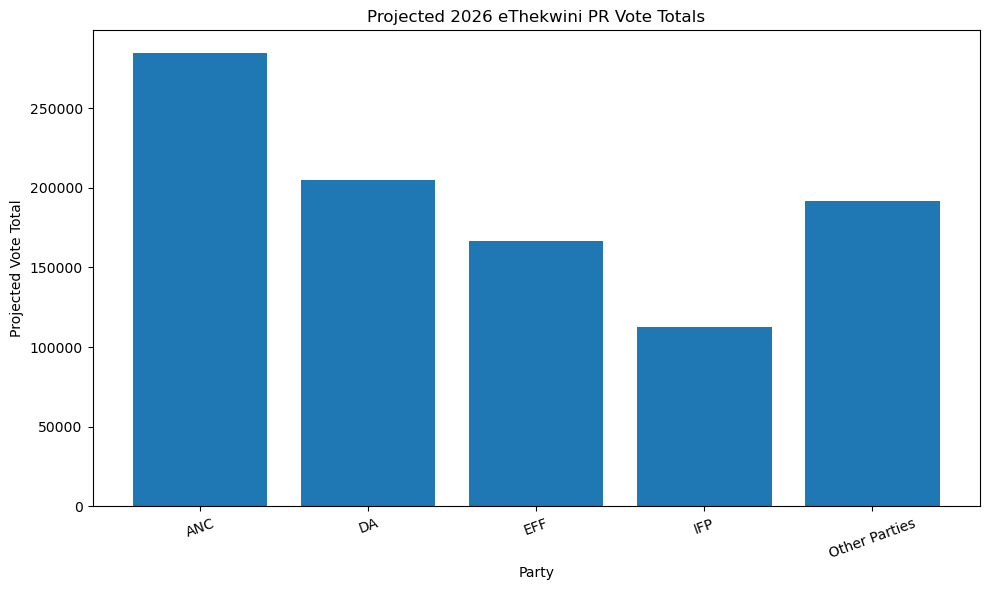

In [114]:
# 2026 projected party vote totals

plt.figure(figsize=(10, 6))

plt.bar(
    forecast_2026_results["Party"],
    forecast_2026_results["Forecast_2026_Vote_Total"]
)

plt.title("Projected 2026 eThekwini PR Vote Totals")
plt.xlabel("Party")
plt.ylabel("Projected Vote Total")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Forecasting Model Validation

Cross-validation is used to assess how consistently the forecasting models perform on different subsets of the historical ward data.

Because only two election years are available, this validation does not prove future 2026 accuracy. Instead, it provides an estimate of how well the models reproduce the historical 2016-to-2021 vote-share changes across different ward samples.

In [115]:
# Forecasting Model Cross-Validation

from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_forecast_results = []

for party in ["ANC", "DA", "EFF", "IFP"]:
    
    X_forecast = forecast_change_df[forecast_features]
    y_forecast = forecast_change_df[f"{party}_Share_Change"]
    
    fold_mae = []
    fold_rmse = []
    fold_r2 = []
    
    for train_index, val_index in kf.split(X_forecast):
        
        X_train_cv = X_forecast.iloc[train_index]
        X_val_cv = X_forecast.iloc[val_index]
        y_train_cv = y_forecast.iloc[train_index]
        y_val_cv = y_forecast.iloc[val_index]
        
        model_cv = RandomForestRegressor(
            n_estimators=200,
            max_depth=5,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42
        )
        
        model_cv.fit(X_train_cv, y_train_cv)
        
        y_pred_cv = model_cv.predict(X_val_cv)
        
        fold_mae.append(
            mean_absolute_error(y_val_cv, y_pred_cv)
        )
        
        fold_rmse.append(
            np.sqrt(mean_squared_error(y_val_cv, y_pred_cv))
        )
        
        fold_r2.append(
            r2_score(y_val_cv, y_pred_cv)
        )
    
    cv_forecast_results.append({
        "Party": party,
        "Mean_CV_MAE": np.mean(fold_mae),
        "Mean_CV_RMSE": np.mean(fold_rmse),
        "Mean_CV_R2": np.mean(fold_r2)
    })

cv_forecast_results = pd.DataFrame(cv_forecast_results)

print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 70)
print(cv_forecast_results.round(4).to_string(index=False))

5-FOLD CROSS-VALIDATION RESULTS
Party  Mean_CV_MAE  Mean_CV_RMSE  Mean_CV_R2
  ANC       0.0515        0.0644      0.3155
   DA       0.0253        0.0414      0.1313
  EFF       0.0295        0.0387      0.4813
  IFP       0.0243        0.0378     -0.5119


## Forecasting Validation Interpretation

The 5-fold cross-validation results show that forecasting performance varies between political parties.

- **ANC:** Mean CV MAE = 0.0515, RMSE = 0.0644 and R² = 0.3155. The model provides a moderate explanation of historical ANC vote-share changes.
- **DA:** Mean CV MAE = 0.0253, RMSE = 0.0414 and R² = 0.1313. The model has limited explanatory power for DA vote-share changes.
- **EFF:** Mean CV MAE = 0.0295, RMSE = 0.0387 and R² = 0.4813. The model provides the strongest cross-validated explanatory performance among the four parties.
- **IFP:** Mean CV MAE = 0.0243, RMSE = 0.0378 and R² = -0.5119. The negative R² indicates that the model performs poorly for explaining IFP vote-share changes across unseen validation folds.

The results demonstrate that the forecasting stage has uncertainty, particularly for the IFP. This is expected because the analysis contains only two historical election periods, limiting the amount of temporal information available for forecasting.

Therefore, the 2026 figures should be presented as **scenario-based machine-learning estimates rather than guaranteed election outcomes**.

#  Clustering Analysis

## Objective

Clustering is used to identify groups of eThekwini wards with similar electoral and demographic characteristics.

The clustering analysis uses 2021 party vote shares together with demographic indicators from Stats SA. This can help identify wards with similar electoral profiles without assigning predefined party labels.

K-Means clustering is used because the selected features are numerical and the method provides a simple and interpretable approach for grouping wards.

In [117]:
# Prepare Data for Clustering

clustering_features = [
    "ANC_Share_2021",
    "DA_Share_2021",
    "EFF_Share_2021",
    "IFP_Share_2021",
    "Youth_Share",
    "WorkingAge_Share",
    "Older_Share"
]

X_cluster = master_df[clustering_features].copy()

cluster_scaler = StandardScaler()

X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

print("CLUSTERING DATA")
print("=" * 50)
print("Number of wards:", X_cluster.shape[0])
print("Number of features:", X_cluster.shape[1])
print("Missing values:", X_cluster.isnull().sum().sum())
print("Scaled data shape:", X_cluster_scaled.shape)

CLUSTERING DATA
Number of wards: 110
Number of features: 7
Missing values: 0
Scaled data shape: (110, 7)


In [118]:
# Determine the Optimal Number of Clusters

k_values = range(2, 7)
silhouette_scores = []

for k in k_values:
    kmeans_test = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    cluster_labels = kmeans_test.fit_predict(X_cluster_scaled)
    
    score = silhouette_score(
        X_cluster_scaled,
        cluster_labels
    )
    
    silhouette_scores.append(score)

cluster_evaluation = pd.DataFrame({
    "Number_of_Clusters": list(k_values),
    "Silhouette_Score": silhouette_scores
})

print("K-MEANS CLUSTER EVALUATION")
print("=" * 50)
print(cluster_evaluation.round(4).to_string(index=False))

best_k = cluster_evaluation.loc[
    cluster_evaluation["Silhouette_Score"].idxmax(),
    "Number_of_Clusters"
]

print("\nBest number of clusters:", best_k)

K-MEANS CLUSTER EVALUATION
 Number_of_Clusters  Silhouette_Score
                  2            0.4771
                  3            0.3864
                  4            0.4003
                  5            0.3520
                  6            0.2900

Best number of clusters: 2


In [119]:
# Final K-Means Clustering

kmeans_model = KMeans(
    n_clusters=int(best_k),
    random_state=42,
    n_init=10
)

master_df["Cluster"] = kmeans_model.fit_predict(
    X_cluster_scaled
)

print("FINAL K-MEANS CLUSTERING")
print("=" * 50)
print("Number of clusters:", best_k)
print("Silhouette score:", round(
    silhouette_score(X_cluster_scaled, master_df["Cluster"]), 4
))

print("\nWards per cluster:")
print(
    master_df["Cluster"]
    .value_counts()
    .sort_index()
)

FINAL K-MEANS CLUSTERING
Number of clusters: 2
Silhouette score: 0.4771

Wards per cluster:
Cluster
0    72
1    38
Name: count, dtype: int64


In [120]:
# Interpret the Clusters

cluster_profile = (
    master_df
    .groupby("Cluster")[clustering_features]
    .mean()
)

cluster_profile_percent = cluster_profile * 100

print("CLUSTER PROFILES")
print("=" * 70)
print(cluster_profile_percent.round(2).to_string())

CLUSTER PROFILES
         ANC_Share_2021  DA_Share_2021  EFF_Share_2021  IFP_Share_2021  Youth_Share  WorkingAge_Share  Older_Share
Cluster                                                                                                           
0                 56.93           6.55           15.68           10.18        40.62             54.70         4.68
1                 20.34          54.40            4.45            4.48        29.36             59.22        11.42


## Cluster Interpretation

The K-Means analysis identified two distinct groups of wards.

**Cluster 0 contains 72 wards.** It has an average ANC vote share of 56.93%, compared with 6.55% for the DA. It also has higher average EFF and IFP shares than Cluster 1. The cluster has a relatively higher youth share of 40.62%.

**Cluster 1 contains 38 wards.** It has an average DA vote share of 54.40%, compared with 20.34% for the ANC. It also has a higher average older-population share of 11.42%.

The clustering therefore identifies two broad electoral profiles: a predominantly ANC-oriented group and a predominantly DA-oriented group.

The silhouette score of 0.4771 indicates a reasonably meaningful separation between the two clusters. However, clustering identifies similarity between wards and does not establish causation between demographic characteristics and voting behaviour.

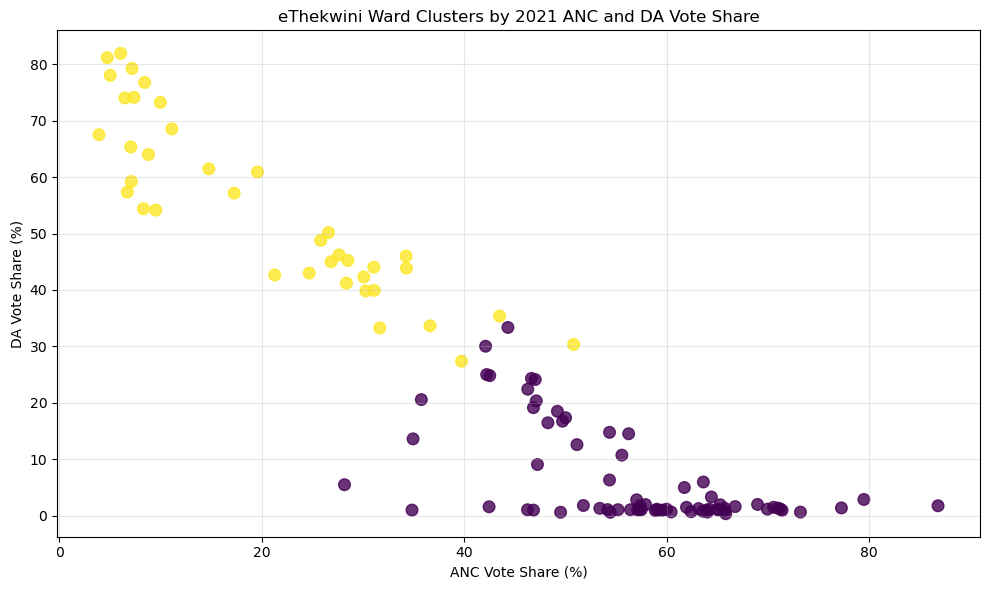

In [121]:
# Visualize Ward Clusters

plt.figure(figsize=(10, 6))

plt.scatter(
    master_df["ANC_Share_2021"] * 100,
    master_df["DA_Share_2021"] * 100,
    c=master_df["Cluster"],
    s=70,
    alpha=0.8
)

plt.title("eThekwini Ward Clusters by 2021 ANC and DA Vote Share")
plt.xlabel("ANC Vote Share (%)")
plt.ylabel("DA Vote Share (%)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#  Streamlit Dashboard / User Interface

## Dashboard Objective

A Streamlit dashboard is developed to provide an interactive interface for presenting the results of the analysis.

The dashboard will allow users to explore:

- 2026 projected party vote totals and vote shares
- Projected voter turnout
- The three selected ward projections
- Historical 2016 and 2021 party results
- Ward clustering results
- Key machine-learning model performance measures

The dashboard is designed to make the analytical results easier to understand and interact with without requiring the user to inspect the underlying Python code.

# Complexity Analysis

Complexity analysis evaluates the computational cost of the main algorithms used in this project.

### Logistic Regression
Logistic Regression has approximately **O(n × p × i)** training complexity, where:
- n = number of training observations
- p = number of features
- i = number of iterations

### Decision Tree
Decision Tree training is approximately **O(n × p × log(n))** under typical balanced-tree conditions.

### Random Forest
Random Forest has approximately **O(t × n × p × log(n))** training complexity, where:
- t = number of trees
- n = number of observations
- p = number of features

The Random Forest used in this project contains **200 trees**, which increases computational cost compared with a single Decision Tree.

### K-Means Clustering
K-Means has approximately **O(n × k × p × i)** complexity, where:
- n = number of wards
- k = number of clusters
- p = number of clustering features
- i = number of iterations

### Overall Complexity

The dataset contains only **110 common wards** and a relatively small number of features. Therefore, the selected algorithms are computationally practical and can execute efficiently on a standard computer.

Although Random Forest is more computationally expensive than Logistic Regression and a single Decision Tree, its cross-validation performance justified its selection as the final classification model.

In [122]:
print("COMPLEXITY ANALYSIS")
print("=" * 60)

print("Dataset size used for modelling:", X.shape)
print("Number of classification features:", X.shape[1])
print("Number of wards:", len(master_df))

print("\nClassification algorithms:")
print("Logistic Regression : O(n × p × i)")
print("Decision Tree       : O(n × p × log(n))")
print("Random Forest       : O(t × n × p × log(n))")

print("\nClustering algorithm:")
print("K-Means             : O(n × k × p × i)")

print("\nRandom Forest trees :", 200)
print("K-Means clusters   :", int(best_k))

print("\nThe algorithms are computationally practical for this dataset.")

COMPLEXITY ANALYSIS
Dataset size used for modelling: (110, 9)
Number of classification features: 9
Number of wards: 110

Classification algorithms:
Logistic Regression : O(n × p × i)
Decision Tree       : O(n × p × log(n))
Random Forest       : O(t × n × p × log(n))

Clustering algorithm:
K-Means             : O(n × k × p × i)

Random Forest trees : 200
K-Means clusters   : 2

The algorithms are computationally practical for this dataset.


# Code Organization and Documentation

The project is organized into logical stages to improve readability,
maintainability and reproducibility.

The main stages are:

1. Student information and project introduction
2. Dataset sources and justification
3. Library imports
4. Loading the 2016, 2021 and Stats SA datasets
5. Data understanding
6. Data preprocessing
7. Exploratory data analysis (EDA)
8. Feature engineering
9. Machine learning implementation
10. Model validation and evaluation
11. Model improvement
12. Ward-level analysis
13. Voter turnout analysis
14. 2026 forecasting
15. Clustering analysis
16. Streamlit dashboard development
17. Complexity analysis
18. Conclusion

Meaningful variable names are used throughout the project, such as
`master_df`, `forecast_2026_results`, `selected_wards` and
`cluster_profile`.

Comments and Markdown explanations are included before major
processing stages to explain the purpose of the code.

The project is reproducible because the datasets, data-processing
steps, feature-engineering procedures, machine-learning algorithms,
evaluation metrics and forecasting methodology are documented.

The Streamlit application is separated from the notebook so that
the analytical processing and the user interface remain organized
as separate components.

# Conclusion

This project developed a complete machine-learning solution for
data-driven electoral analysis of eThekwini Metropolitan Municipality.

The analysis combined IEC Local Government Election results from
2016 and 2021 with ward-level demographic data from Statistics South
Africa.

The data was cleaned, standardized and integrated using ward codes.
Exploratory data analysis was then performed to identify historical
party-support patterns and demographic characteristics.

Three classification algorithms were evaluated: Logistic Regression,
Decision Tree and Random Forest. Random Forest was selected as the
final classification model because it achieved the highest mean
cross-validation accuracy of **97.2%**. The final model achieved
**94.1% test accuracy**.

The analysis also identified three geographically comparable wards
for detailed analysis, estimated voter turnout, and grouped wards
using K-Means clustering.

The 2026 scenario forecast estimated:

- **ANC:** 284,608 votes (29.63%)
- **DA:** 204,970 votes (21.34%)
- **EFF:** 166,811 votes (17.37%)
- **IFP:** 112,493 votes (11.71%)
- **Other Parties:** 191,663 votes (19.95%)

The projected voter turnout was **50.31%**, corresponding to
approximately **960,545 voters**.

No single party reached 50% in the scenario forecast, meaning that
coalition arrangements could be relevant. However, the model does
not determine which party will govern the municipality, since
governance depends on council seat allocation, coalition agreements
and other political factors.

The forecasting results should be interpreted as **scenario-based
machine-learning estimates rather than guaranteed future election
results**. The limited number of historical election periods is an
important limitation of the forecasting analysis.

Overall, the project demonstrates how machine learning, exploratory
data analysis, clustering, forecasting and an interactive Streamlit
dashboard can be combined to produce a complete data-driven
analytical solution.